In [18]:
import pandas as pd
armas1 = pd.read_csv(r'D:\Project_ML_class\data\processed\armas1_processed.csv')
armas2 = pd.read_csv(r'D:\Project_ML_class\data\processed\armas2_processed.csv')
armas3 = pd.read_csv(r'D:\Project_ML_class\data\processed\armas3_processed.csv')
armas_all =pd.read_csv(r'D:\Project_ML_class\data\processed\armas_all_processed.csv')

# import libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline       
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Copy your train,validation and test sets

In [20]:
train_df = armas1.copy()
valid_df = armas2.copy()    
test_df  = armas3.copy()

# Define the target and columns to remove

In [21]:
TARGET = 'Index_K'

DROP_COLS = [TARGET, 'NAIRASV3', 'NAIRASV2', 'Datetime', 'Vehicle_ID', 'ARMAS']

# Separate input features X and output y

In [22]:
def split_xy(df):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    y = df[TARGET]
    return X, y
X_train, y_train = split_xy(train_df)
X_valid, y_valid = split_xy(valid_df)
X_test, y_test   = split_xy(test_df)

In [23]:
print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test shape :", X_test.shape)

print("\nTrain class counts:")
print(y_train.value_counts().sort_index())

Train shape: (32380, 43)
Valid shape: (30787, 43)
Test shape : (29309, 43)

Train class counts:
Index_K
0     8871
1    18185
2     5324
Name: count, dtype: int64


Detect the numeric and categorical columns

In [24]:
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Latitude', 'Longitude', 'Altitude(Bar)', 'Altitude(GPS)', 'Geomagnetic_latitude', 'Geomagnetic_longitude', 'Geomagnetic_Rc', 'Geomagnetic_Lshell', 'NM_NEWK', 'NM_OULU', 'NM_THUL', 'NM_SOPO', 'SXR_short', 'SXR_long', 'Particles_P1', 'Particles_P5', 'Particles_P10', 'Particles_P30', 'Particles_P50', 'Particles_P100', 'Particles_E20', 'SW_B', 'SW_Bx', 'SW_By', 'SW_Bz', 'SW_V', 'SW_Vx', 'SW_Vy', 'SW_Vz', 'SW_density', 'SW_temperature', 'SW_pressure', 'Index_Kp', 'Index_Dst', 'Index_Ap', 'Solar_sunspots', 'Solar_f107', 'Solar_NPF', 'Solar_SPF', 'Solar_APF', 'Solar_NPF20', 'Solar_SPF20', 'Solar_APF20']
Categorical columns: []


Build preprocessing pipeline

In [25]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

Manual Tuining of logistic regression

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [27]:
datasets = {
    "armas1": armas1,
    "armas2": armas2,
    "armas3": armas3
}

In [28]:
rotations = [
    ("armas1", "armas2", "armas3"),
    ("armas1", "armas3", "armas2"),
    ("armas2", "armas1", "armas3"),
    ("armas2", "armas3", "armas1"),
    ("armas3", "armas1", "armas2"),
    ("armas3", "armas2", "armas1")
]


ROTATION: Train=armas1, Validation=armas2, Test=armas3

Best C selected: 1.3738237958832638
Equivalent lambda: 0.7278953843983146
Best validation Macro F1: 0.6408
Test Accuracy: 0.6485
Test Macro F1: 0.6475

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69      8813
           1       0.72      0.56      0.63     15538
           2       0.52      0.76      0.62      4958

    accuracy                           0.65     29309
   macro avg       0.63      0.69      0.65     29309
weighted avg       0.67      0.65      0.65     29309


ROTATION: Train=armas1, Validation=armas3, Test=armas2

Best C selected: 0.20433597178569418
Equivalent lambda: 4.8939009184774935
Best validation Macro F1: 0.6464
Test Accuracy: 0.6418
Test Macro F1: 0.6403

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70      9452
           1       0.72      0.54      0.62  

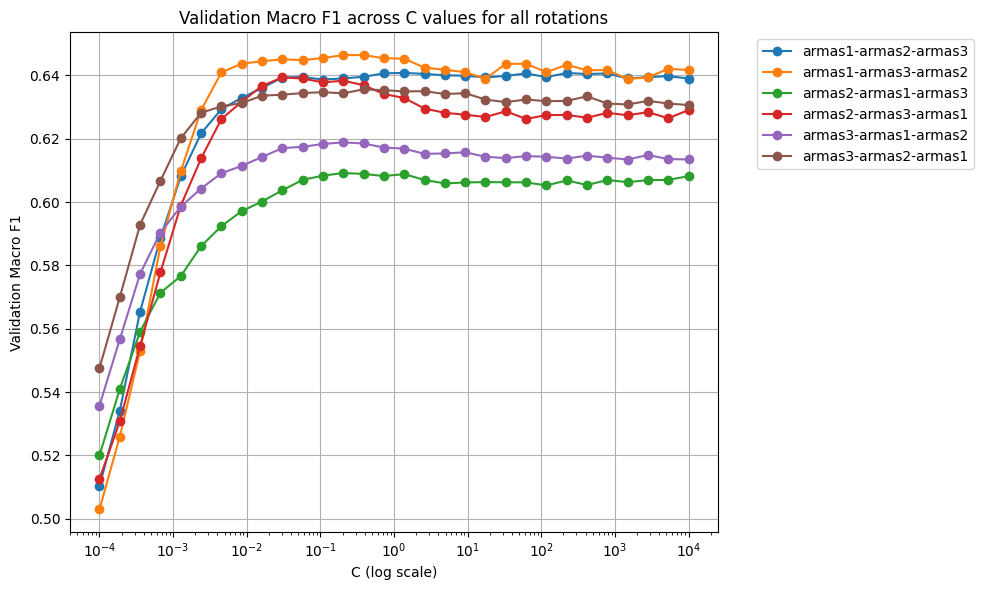

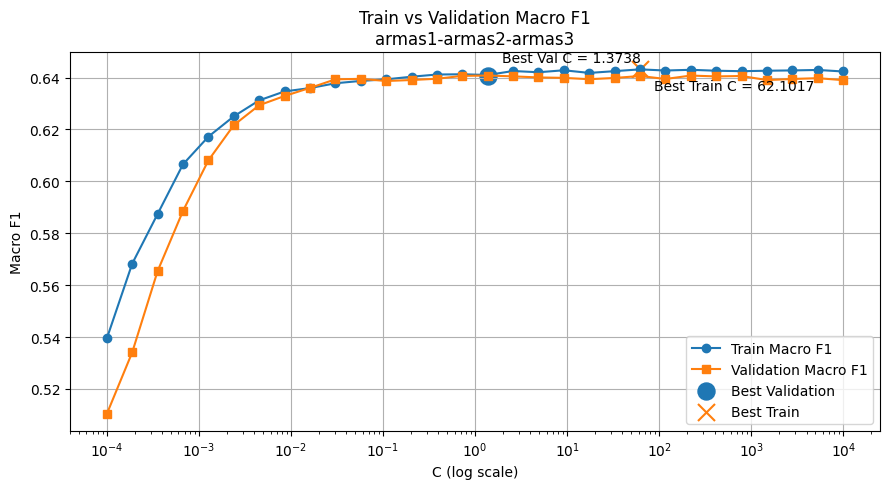

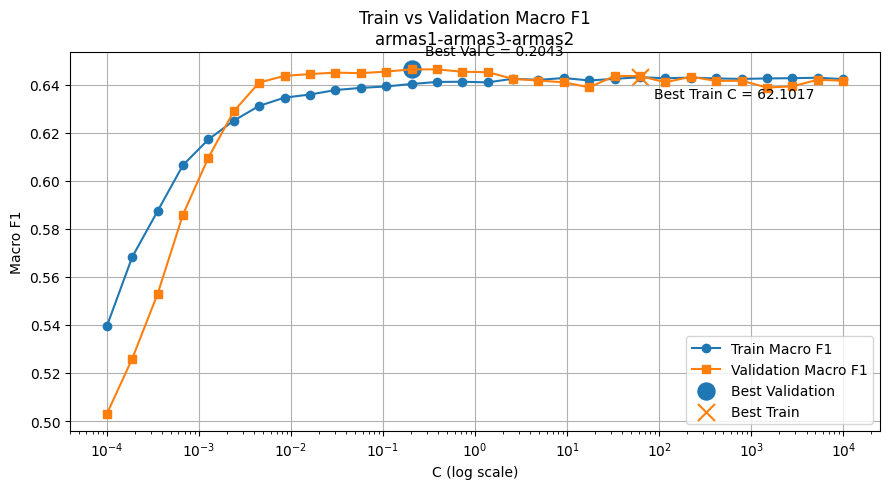

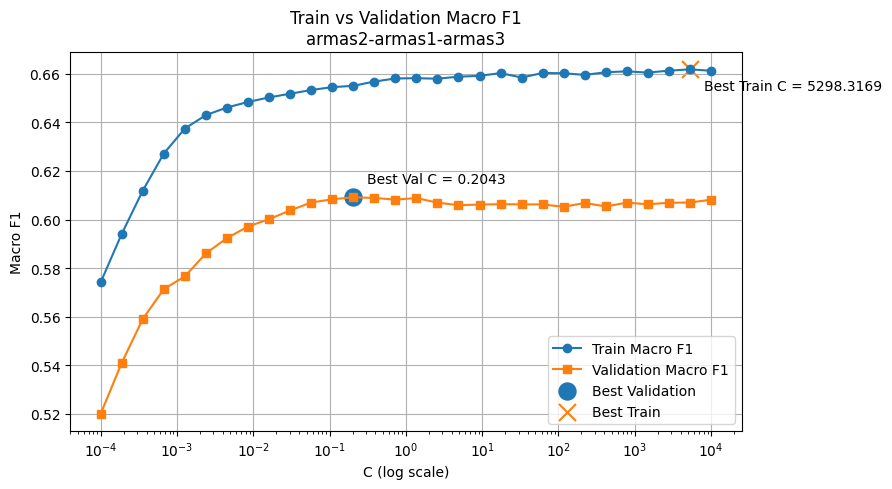

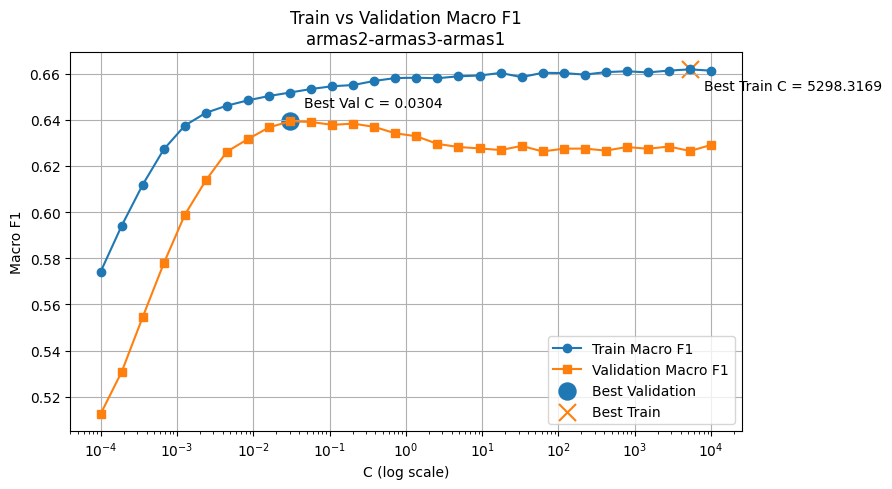

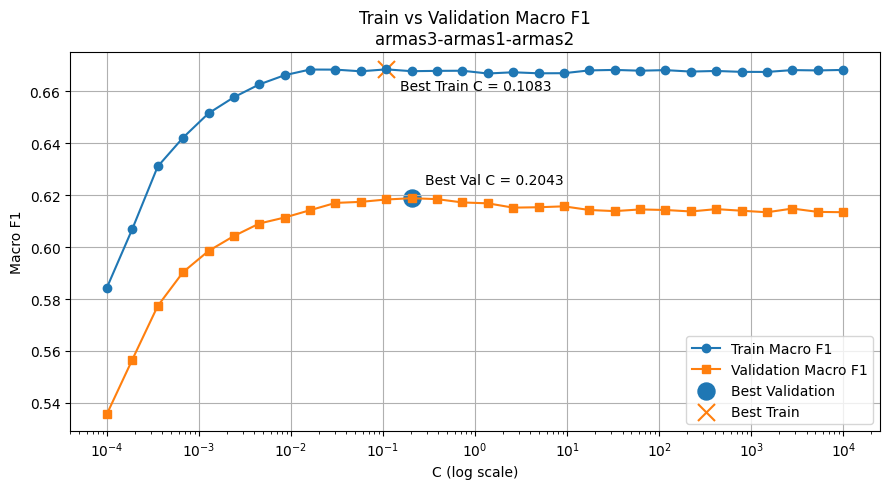

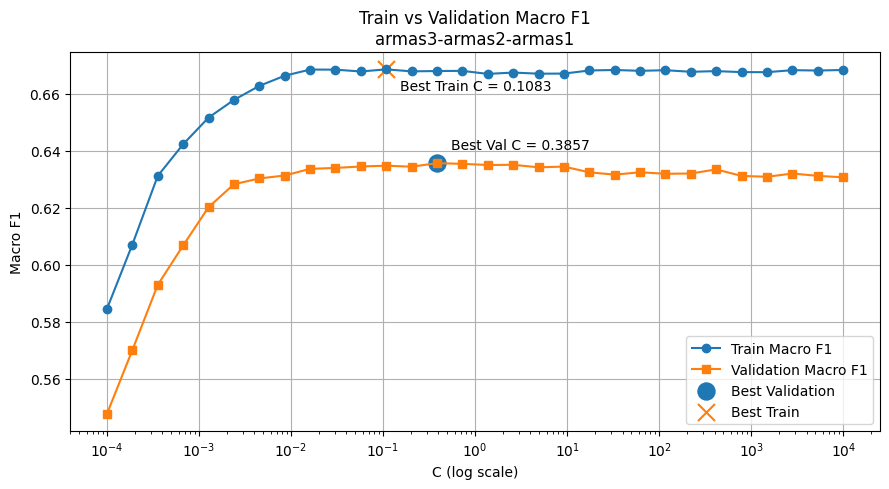

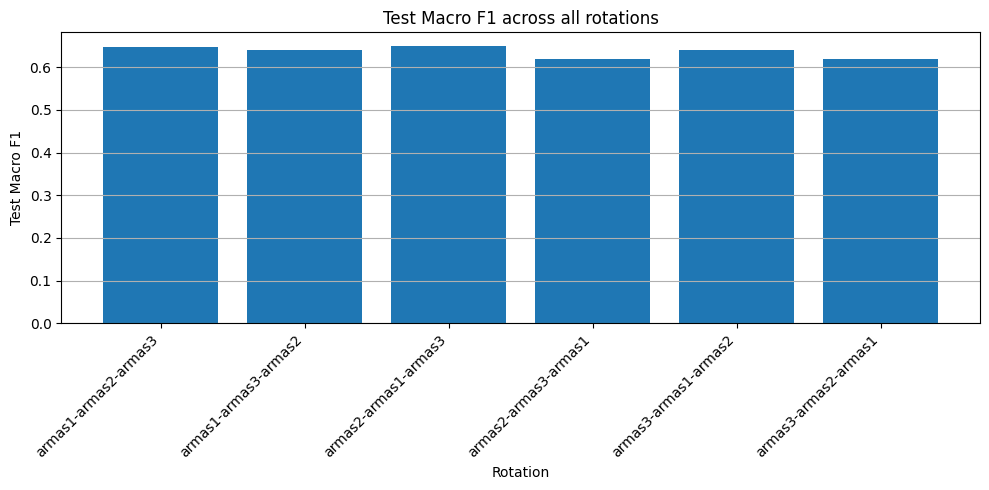

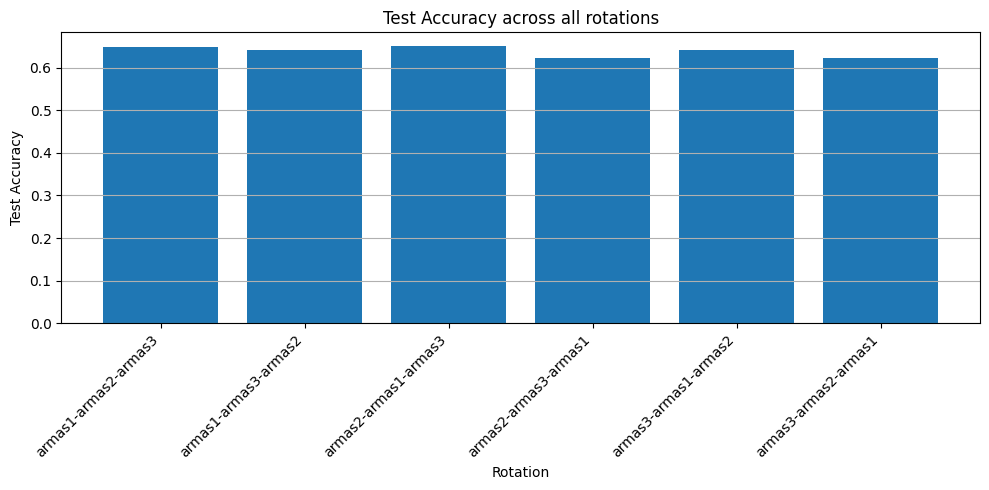

C:\Users\physi\AppData\Local\Temp\ipykernel_11392\4205455208.py:325: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


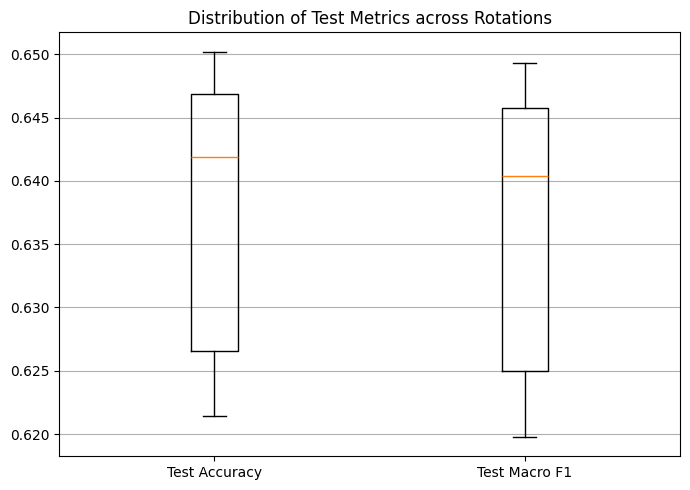

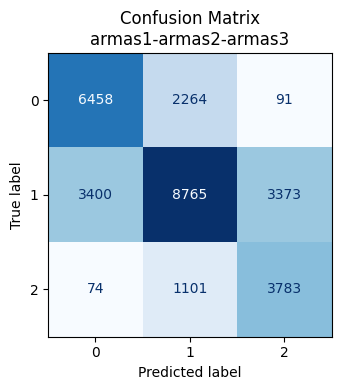

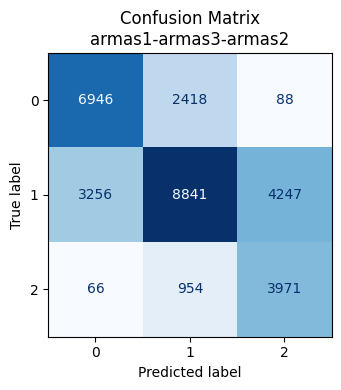

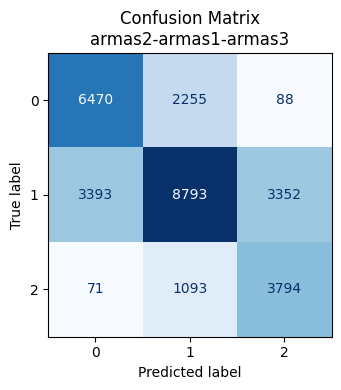

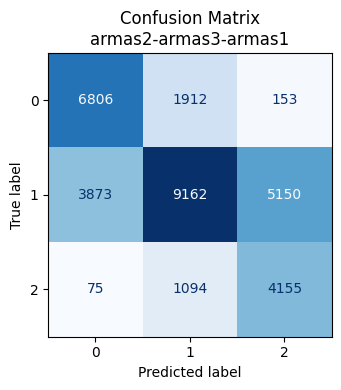

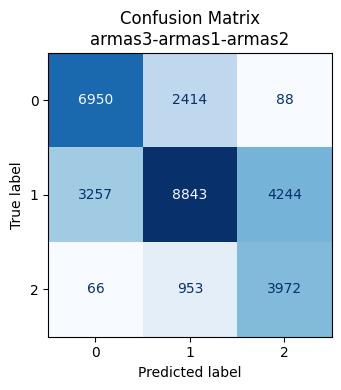

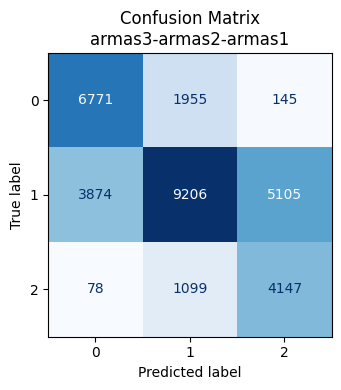

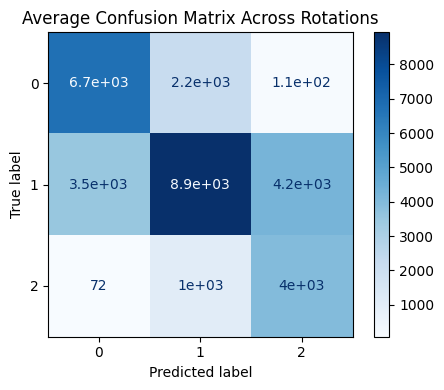

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 1. DEFINE YOUR THREE DATASETS
# =========================================================
# Make sure armas1, armas2, armas3 already exist

datasets = {
    "armas1": armas1.copy(),
    "armas2": armas2.copy(),
    "armas3": armas3.copy()
}

# =========================================================
# 2. DEFINE TARGET AND COLUMNS TO DROP
# =========================================================
TARGET = 'Index_K'
DROP_COLS = [TARGET, 'NAIRASV3', 'NAIRASV2', 'Datetime', 'Vehicle_ID', 'ARMAS']

# =========================================================
# 3. FUNCTION TO SPLIT X AND y
# =========================================================
def split_xy(df):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    y = df[TARGET].copy()
    return X, y

# =========================================================
# 4. BUILD PREPROCESSOR
#    We use armas1 just to detect column types.
#    This assumes all three datasets have the same feature columns.
# =========================================================
X_sample, y_sample = split_xy(datasets["armas1"])

numeric_cols = X_sample.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_sample.select_dtypes(exclude=['number']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# preprocessor = ColumnTransformer([
#     ('num', numeric_pipe, numeric_cols),
#     ('cat', categorical_pipe, categorical_cols)
# ])

# =========================================================
# 5. CREATE ALL 6 ROTATIONS
# =========================================================
rotations = list(permutations(datasets.keys(), 3))

# Example:
# ('armas1', 'armas2', 'armas3')
# ('armas1', 'armas3', 'armas2')
# ('armas2', 'armas1', 'armas3')
# ('armas2', 'armas3', 'armas1')
# ('armas3', 'armas1', 'armas2')
# ('armas3', 'armas2', 'armas1')

# =========================================================
# 6. SET SEARCH RANGE FOR C
# =========================================================
C_values = np.logspace(-4, 4, 30)

# Containers to store all results
all_results = []
curve_data = []
all_conf_matrices = []

# =========================================================
# 7. MAIN LOOP OVER ALL ROTATIONS
# =========================================================
for train_name, valid_name, test_name in rotations:

    print("\n" + "=" * 80)
    print(f"ROTATION: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print("=" * 80)

    train_df = datasets[train_name].copy()
    valid_df = datasets[valid_name].copy()
    test_df = datasets[test_name].copy()

    X_train, y_train = split_xy(train_df)
    X_valid, y_valid = split_xy(valid_df)
    X_test, y_test = split_xy(test_df)

    rotation_results = []

    # -----------------------------------------------------
    # Tune C using validation set
    # -----------------------------------------------------
    for c in C_values:
        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                C=c,
                max_iter=2000,
                class_weight='balanced',
                solver='lbfgs'
            ))
        ])

        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_valid_pred = model.predict(X_valid)

        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')

        valid_acc = accuracy_score(y_valid, y_valid_pred)
        valid_f1 = f1_score(y_valid, y_valid_pred, average='macro')

        rotation_results.append({
            'train_set': train_name,
            'valid_set': valid_name,
            'test_set': test_name,
            'C': c,
            'lambda_equivalent': 1 / c,
            'train_accuracy': train_acc,
            'train_f1_macro': train_f1,
            'valid_accuracy': valid_acc,
            'valid_f1_macro': valid_f1
        })

    rotation_df = pd.DataFrame(rotation_results).sort_values('valid_f1_macro', ascending=False)
    best_row = rotation_df.iloc[0]
    best_c = best_row['C']
    best_lambda = 1 / best_c

    print(f"\nBest C selected: {best_c}")
    print(f"Equivalent lambda: {best_lambda}")
    print(f"Best validation Macro F1: {best_row['valid_f1_macro']:.4f}")

    # Save tuning curve data
    curve_data.append(rotation_df.copy())

    # -----------------------------------------------------
    # Retrain final model on TRAIN + VALIDATION
    # -----------------------------------------------------
    X_train_final = pd.concat([X_train, X_valid], axis=0)
    y_train_final = pd.concat([y_train, y_valid], axis=0)

    final_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            C=best_c,
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs'
        ))
    ])

    final_model.fit(X_train_final, y_train_final)

    # -----------------------------------------------------
    # Evaluate on TEST
    # -----------------------------------------------------
    y_test_pred = final_model.predict(X_test)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    cm = confusion_matrix(y_test, y_test_pred)

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    all_results.append({
        'train_set': train_name,
        'valid_set': valid_name,
        'test_set': test_name,
        'best_c': best_c,
        'best_lambda': best_lambda,
        'best_train_f1_macro': best_row['train_f1_macro'],
        'best_valid_f1_macro': best_row['valid_f1_macro'],
        'test_accuracy': test_acc,
        'test_f1_macro': test_f1
    })

    all_conf_matrices.append({
        'rotation': f"{train_name}-{valid_name}-{test_name}",
        'cm': cm
    })

# =========================================================
# 8. FINAL RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("ALL ROTATION RESULTS")
print("=" * 80)
print(results_df)

print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE ACROSS ALL 6 ROTATIONS")
print("=" * 80)
print(f"Average Test Accuracy : {results_df['test_accuracy'].mean():.4f}")
print(f"Std Test Accuracy     : {results_df['test_accuracy'].std():.4f}")
print(f"Average Test Macro F1 : {results_df['test_f1_macro'].mean():.4f}")
print(f"Std Test Macro F1     : {results_df['test_f1_macro'].std():.4f}")

# =========================================================
# 9. PLOT 1: VALIDATION F1 VS C FOR ALL ROTATIONS
# =========================================================
plt.figure(figsize=(10, 6))

for df_curve in curve_data:
    df_curve_sorted = df_curve.sort_values('C')
    label = f"{df_curve_sorted.iloc[0]['train_set']}-{df_curve_sorted.iloc[0]['valid_set']}-{df_curve_sorted.iloc[0]['test_set']}"
    plt.plot(
        df_curve_sorted['C'],
        df_curve_sorted['valid_f1_macro'],
        marker='o',
        label=label
    )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Validation Macro F1')
plt.title('Validation Macro F1 across C values for all rotations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 10. PLOT 2: TRAIN VS VALIDATION F1 FOR EACH ROTATION
# =========================================================
for df_curve in curve_data:
    df_curve_sorted = df_curve.sort_values('C')
    rotation_label = f"{df_curve_sorted.iloc[0]['train_set']}-{df_curve_sorted.iloc[0]['valid_set']}-{df_curve_sorted.iloc[0]['test_set']}"

    best_valid = df_curve_sorted.loc[df_curve_sorted['valid_f1_macro'].idxmax()]
    best_train = df_curve_sorted.loc[df_curve_sorted['train_f1_macro'].idxmax()]

    plt.figure(figsize=(9, 5))

    plt.plot(df_curve_sorted['C'], df_curve_sorted['train_f1_macro'], marker='o', label='Train Macro F1')
    plt.plot(df_curve_sorted['C'], df_curve_sorted['valid_f1_macro'], marker='s', label='Validation Macro F1')

    plt.scatter(best_valid['C'], best_valid['valid_f1_macro'], s=150, label='Best Validation')
    plt.annotate(
        f"Best Val C = {best_valid['C']:.4f}",
        (best_valid['C'], best_valid['valid_f1_macro']),
        textcoords="offset points",
        xytext=(10, 10)
    )

    plt.scatter(best_train['C'], best_train['train_f1_macro'], s=150, marker='x', label='Best Train')
    plt.annotate(
        f"Best Train C = {best_train['C']:.4f}",
        (best_train['C'], best_train['train_f1_macro']),
        textcoords="offset points",
        xytext=(10, -15)
    )

    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('Macro F1')
    plt.title(f'Train vs Validation Macro F1\n{rotation_label}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# 11. PLOT 3: TEST MACRO F1 FOR EACH ROTATION
# =========================================================
rotation_labels = results_df.apply(
    lambda row: f"{row['train_set']}-{row['valid_set']}-{row['test_set']}", axis=1
)

plt.figure(figsize=(10, 5))
plt.bar(rotation_labels, results_df['test_f1_macro'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Rotation')
plt.ylabel('Test Macro F1')
plt.title('Test Macro F1 across all rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 12. PLOT 4: TEST ACCURACY FOR EACH ROTATION
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(rotation_labels, results_df['test_accuracy'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Rotation')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy across all rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 13. PLOT 5: BOXPLOT OF TEST METRICS
# =========================================================
plt.figure(figsize=(7, 5))
plt.boxplot(
    [results_df['test_accuracy'], results_df['test_f1_macro']],
    labels=['Test Accuracy', 'Test Macro F1']
)
plt.title('Distribution of Test Metrics across Rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 14. PLOT 6: CONFUSION MATRIX FOR EACH ROTATION
# =========================================================
for item in all_conf_matrices:
    rotation_name = item['rotation']
    cm = item['cm']

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix\n{rotation_name}")
    plt.tight_layout()
    plt.show()

# =========================================================
# 15. OPTIONAL: AVERAGE CONFUSION MATRIX
#     Only makes sense if all confusion matrices have same shape
# =========================================================
cm_shapes = [item['cm'].shape for item in all_conf_matrices]

if len(set(cm_shapes)) == 1:
    avg_cm = np.mean([item['cm'] for item in all_conf_matrices], axis=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    ax.set_title("Average Confusion Matrix Across Rotations")
    plt.tight_layout()
    plt.show()
else:
    print("\nCould not compute average confusion matrix because shapes differ across rotations.")



ROTATION: Train=armas1, Validation=armas2, Test=armas3

Best C selected: 1.3738237958832638
Equivalent lambda: 0.7278953843983146
Best validation Macro F1: 0.6408
Test Accuracy: 0.6485
Test Macro F1: 0.6475

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69      8813
           1       0.72      0.56      0.63     15538
           2       0.52      0.76      0.62      4958

    accuracy                           0.65     29309
   macro avg       0.63      0.69      0.65     29309
weighted avg       0.67      0.65      0.65     29309


ROTATION: Train=armas1, Validation=armas3, Test=armas2

Best C selected: 0.20433597178569418
Equivalent lambda: 4.8939009184774935
Best validation Macro F1: 0.6464
Test Accuracy: 0.6418
Test Macro F1: 0.6403

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70      9452
           1       0.72      0.54      0.62  

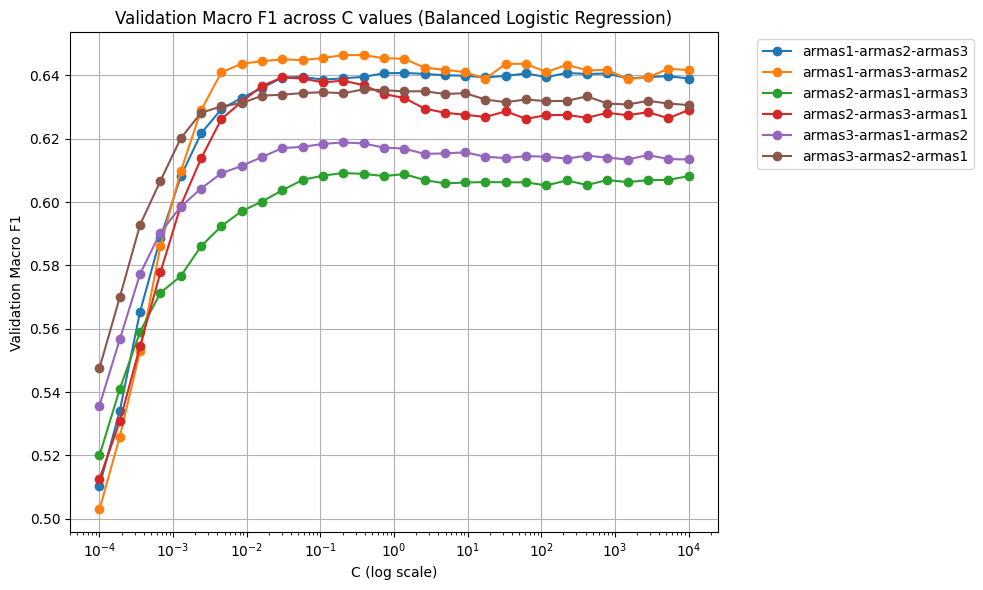

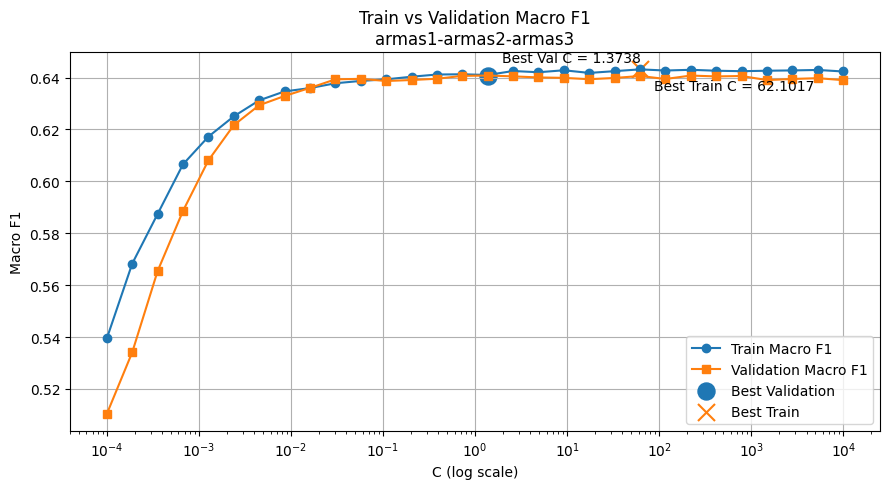

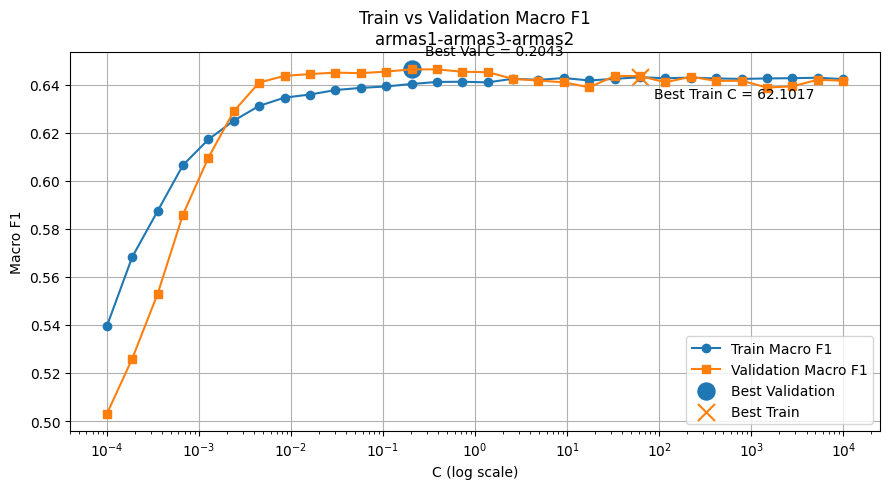

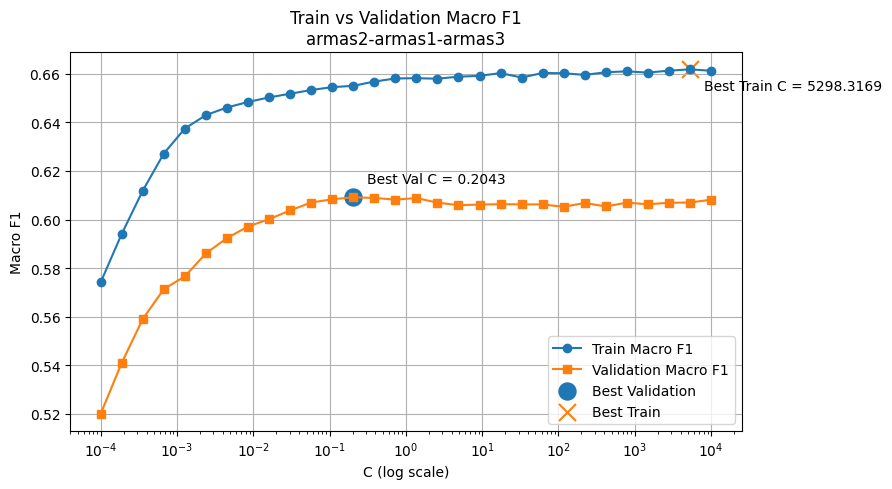

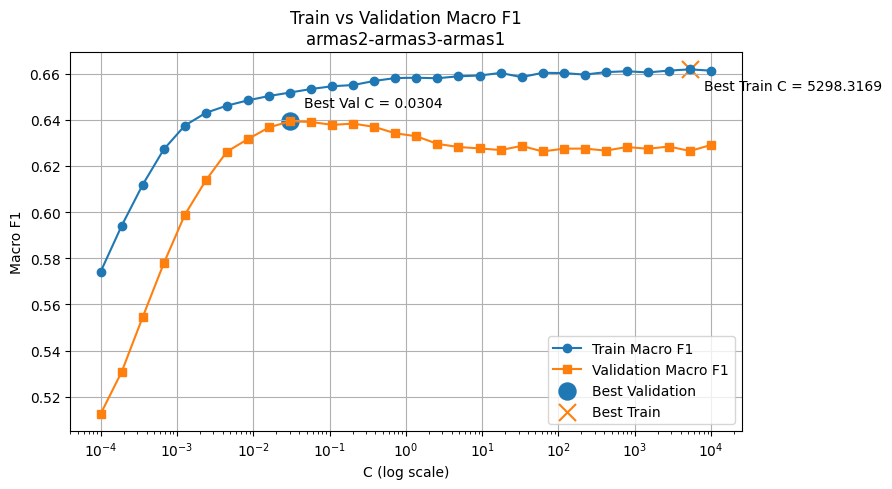

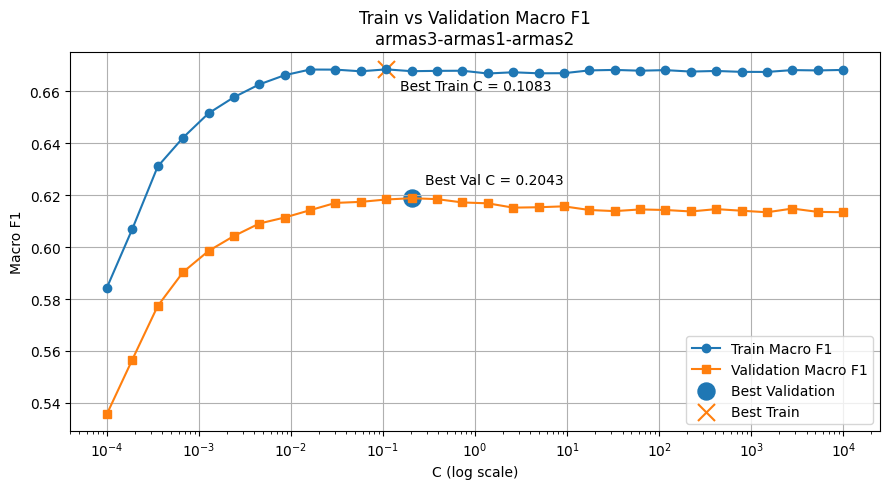

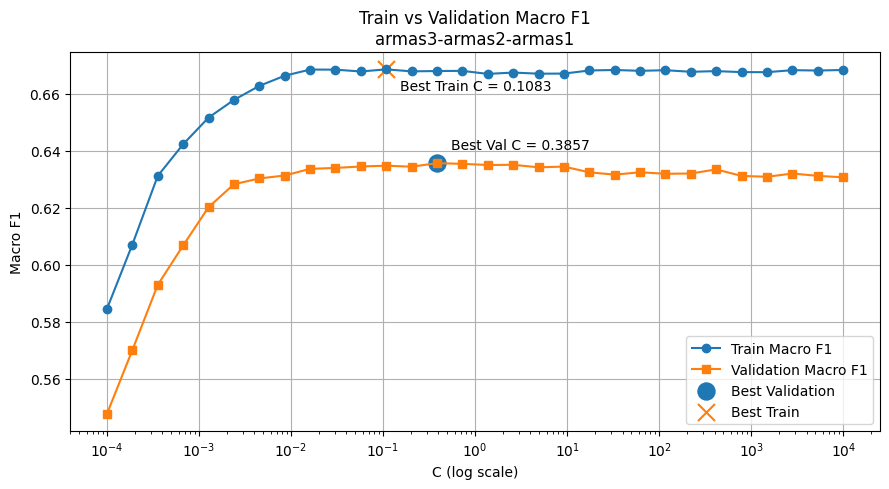

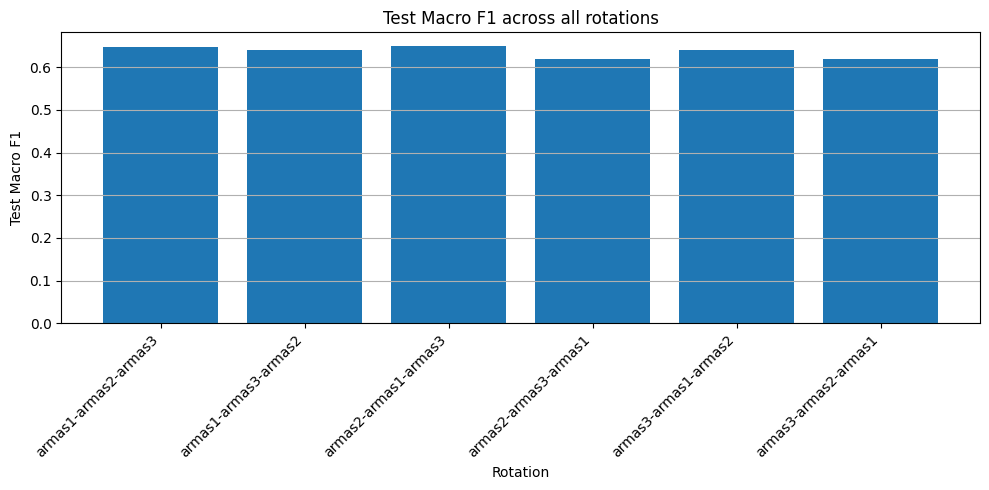

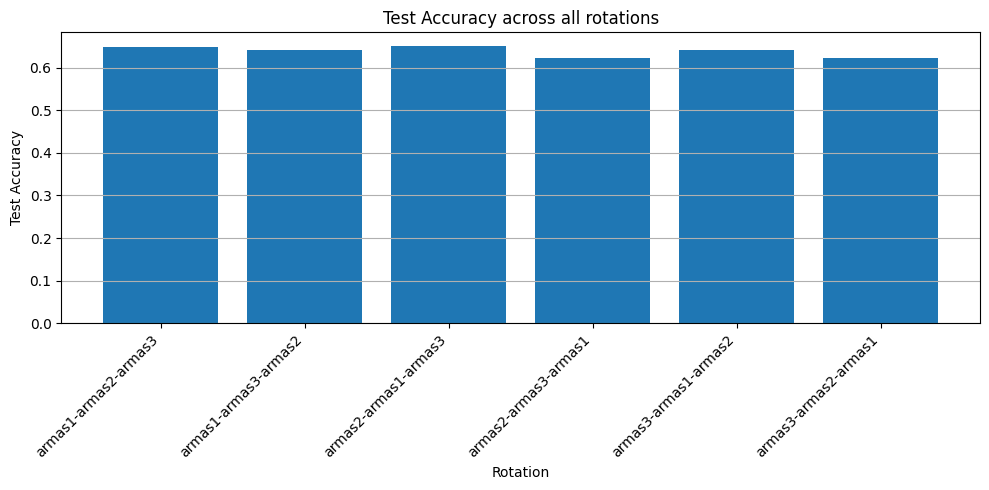

C:\Users\physi\AppData\Local\Temp\ipykernel_11392\2185708291.py:312: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


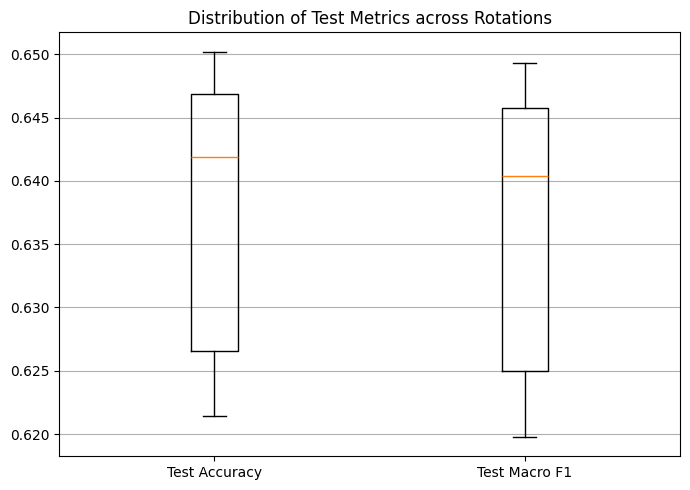

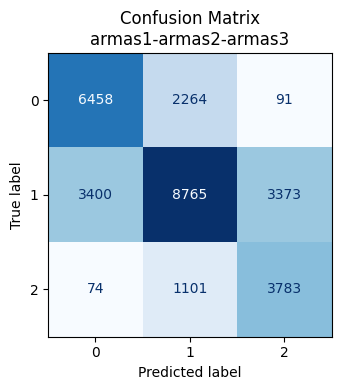

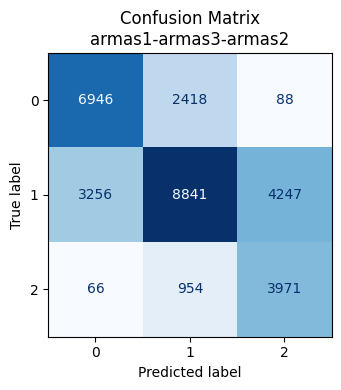

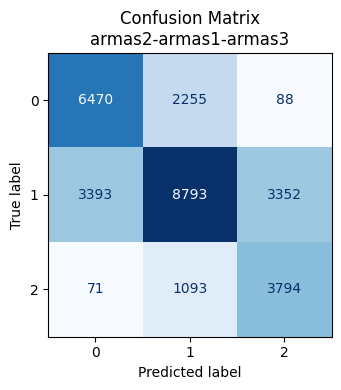

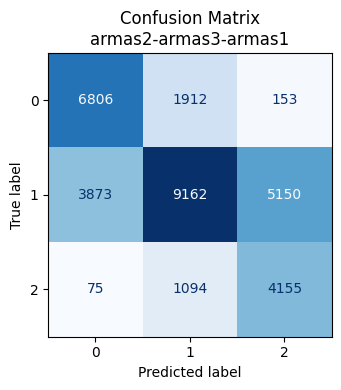

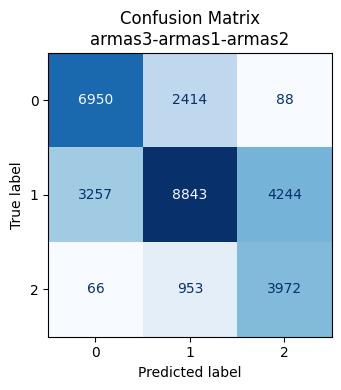

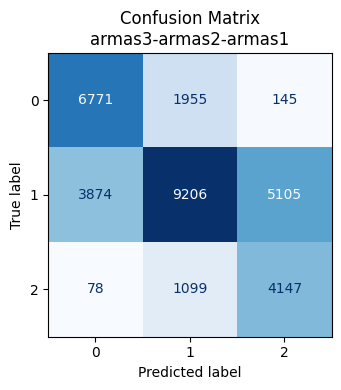

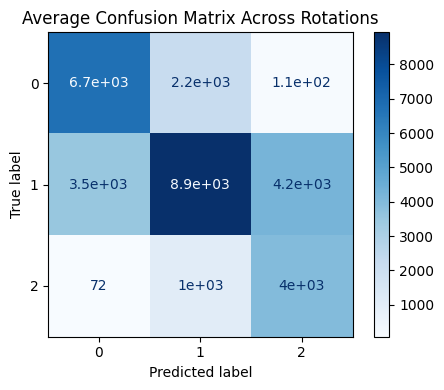

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 1. DEFINE YOUR THREE DATASETS
# =========================================================
datasets = {
    "armas1": armas1.copy(),
    "armas2": armas2.copy(),
    "armas3": armas3.copy()
}

# =========================================================
# 2. DEFINE TARGET AND COLUMNS TO DROP
# =========================================================
TARGET = 'Index_K'
DROP_COLS = [TARGET, 'NAIRASV3', 'NAIRASV2', 'Datetime', 'Vehicle_ID', 'ARMAS']

# =========================================================
# 3. FUNCTION TO SPLIT X AND y
# =========================================================
def split_xy(df):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    y = df[TARGET].copy()
    return X, y

# =========================================================
# 4. BUILD PREPROCESSOR
# =========================================================
X_sample, y_sample = split_xy(datasets["armas1"])

numeric_cols = X_sample.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_sample.select_dtypes(exclude=['number']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# preprocessor = ColumnTransformer([
#     ('num', numeric_pipe, numeric_cols),
#     ('cat', categorical_pipe, categorical_cols)
# ])

# =========================================================
# 5. CREATE ALL 6 TRAIN / VALID / TEST ROTATIONS
# =========================================================
rotations = list(permutations(datasets.keys(), 3))

# =========================================================
# 6. SET SEARCH RANGE FOR C
# =========================================================
C_values = np.logspace(-4, 4, 30)

all_results = []
curve_data = []
all_conf_matrices = []

# =========================================================
# 7. MAIN LOOP
# =========================================================
for train_name, valid_name, test_name in rotations:

    print("\n" + "=" * 80)
    print(f"ROTATION: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print("=" * 80)

    train_df = datasets[train_name].copy()
    valid_df = datasets[valid_name].copy()
    test_df = datasets[test_name].copy()

    X_train, y_train = split_xy(train_df)
    X_valid, y_valid = split_xy(valid_df)
    X_test, y_test = split_xy(test_df)

    rotation_results = []

    # -----------------------------------------------------
    # Tune C using validation set
    # -----------------------------------------------------
    for c in C_values:
        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                C=c,
                max_iter=2000,
                class_weight='balanced',   # <- handles imbalance
                solver='lbfgs'
            ))
        ])

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_valid_pred = model.predict(X_valid)

        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')

        valid_acc = accuracy_score(y_valid, y_valid_pred)
        valid_f1 = f1_score(y_valid, y_valid_pred, average='macro')

        rotation_results.append({
            'train_set': train_name,
            'valid_set': valid_name,
            'test_set': test_name,
            'C': c,
            'lambda_equivalent': 1 / c,
            'train_accuracy': train_acc,
            'train_f1_macro': train_f1,
            'valid_accuracy': valid_acc,
            'valid_f1_macro': valid_f1
        })

    rotation_df = pd.DataFrame(rotation_results).sort_values('valid_f1_macro', ascending=False)
    best_row = rotation_df.iloc[0]
    best_c = best_row['C']
    best_lambda = 1 / best_c

    print(f"\nBest C selected: {best_c}")
    print(f"Equivalent lambda: {best_lambda}")
    print(f"Best validation Macro F1: {best_row['valid_f1_macro']:.4f}")

    curve_data.append(rotation_df.copy())

    # -----------------------------------------------------
    # Retrain final model on TRAIN + VALIDATION
    # -----------------------------------------------------
    X_train_final = pd.concat([X_train, X_valid], axis=0)
    y_train_final = pd.concat([y_train, y_valid], axis=0)

    final_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            C=best_c,
            max_iter=2000,
            class_weight='balanced',   # <- keeps balance handling
            solver='lbfgs'
        ))
    ])

    final_model.fit(X_train_final, y_train_final)

    # -----------------------------------------------------
    # Evaluate on TEST
    # -----------------------------------------------------
    y_test_pred = final_model.predict(X_test)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    cm = confusion_matrix(y_test, y_test_pred)

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    all_results.append({
        'train_set': train_name,
        'valid_set': valid_name,
        'test_set': test_name,
        'best_c': best_c,
        'best_lambda': best_lambda,
        'best_train_f1_macro': best_row['train_f1_macro'],
        'best_valid_f1_macro': best_row['valid_f1_macro'],
        'test_accuracy': test_acc,
        'test_f1_macro': test_f1
    })

    all_conf_matrices.append({
        'rotation': f"{train_name}-{valid_name}-{test_name}",
        'cm': cm
    })

# =========================================================
# 8. FINAL RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("ALL ROTATION RESULTS")
print("=" * 80)
print(results_df)

print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE ACROSS ALL 6 ROTATIONS")
print("=" * 80)
print(f"Average Test Accuracy : {results_df['test_accuracy'].mean():.4f}")
print(f"Std Test Accuracy     : {results_df['test_accuracy'].std():.4f}")
print(f"Average Test Macro F1 : {results_df['test_f1_macro'].mean():.4f}")
print(f"Std Test Macro F1     : {results_df['test_f1_macro'].std():.4f}")

# =========================================================
# 9. PLOT: VALIDATION F1 VS C FOR ALL ROTATIONS
# =========================================================
plt.figure(figsize=(10, 6))

for df_curve in curve_data:
    df_curve_sorted = df_curve.sort_values('C')
    label = f"{df_curve_sorted.iloc[0]['train_set']}-{df_curve_sorted.iloc[0]['valid_set']}-{df_curve_sorted.iloc[0]['test_set']}"
    plt.plot(
        df_curve_sorted['C'],
        df_curve_sorted['valid_f1_macro'],
        marker='o',
        label=label
    )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Validation Macro F1')
plt.title('Validation Macro F1 across C values (Balanced Logistic Regression)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 10. PLOT: TRAIN VS VALIDATION F1 FOR EACH ROTATION
# =========================================================
for df_curve in curve_data:
    df_curve_sorted = df_curve.sort_values('C')
    rotation_label = f"{df_curve_sorted.iloc[0]['train_set']}-{df_curve_sorted.iloc[0]['valid_set']}-{df_curve_sorted.iloc[0]['test_set']}"

    best_valid = df_curve_sorted.loc[df_curve_sorted['valid_f1_macro'].idxmax()]
    best_train = df_curve_sorted.loc[df_curve_sorted['train_f1_macro'].idxmax()]

    plt.figure(figsize=(9, 5))

    plt.plot(df_curve_sorted['C'], df_curve_sorted['train_f1_macro'], marker='o', label='Train Macro F1')
    plt.plot(df_curve_sorted['C'], df_curve_sorted['valid_f1_macro'], marker='s', label='Validation Macro F1')

    plt.scatter(best_valid['C'], best_valid['valid_f1_macro'], s=150, label='Best Validation')
    plt.annotate(
        f"Best Val C = {best_valid['C']:.4f}",
        (best_valid['C'], best_valid['valid_f1_macro']),
        textcoords="offset points",
        xytext=(10, 10)
    )

    plt.scatter(best_train['C'], best_train['train_f1_macro'], s=150, marker='x', label='Best Train')
    plt.annotate(
        f"Best Train C = {best_train['C']:.4f}",
        (best_train['C'], best_train['train_f1_macro']),
        textcoords="offset points",
        xytext=(10, -15)
    )

    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('Macro F1')
    plt.title(f'Train vs Validation Macro F1\n{rotation_label}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# 11. PLOT: TEST MACRO F1 FOR EACH ROTATION
# =========================================================
rotation_labels = results_df.apply(
    lambda row: f"{row['train_set']}-{row['valid_set']}-{row['test_set']}", axis=1
)

plt.figure(figsize=(10, 5))
plt.bar(rotation_labels, results_df['test_f1_macro'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Rotation')
plt.ylabel('Test Macro F1')
plt.title('Test Macro F1 across all rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 12. PLOT: TEST ACCURACY FOR EACH ROTATION
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(rotation_labels, results_df['test_accuracy'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Rotation')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy across all rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 13. BOXPLOT OF TEST METRICS
# =========================================================
plt.figure(figsize=(7, 5))
plt.boxplot(
    [results_df['test_accuracy'], results_df['test_f1_macro']],
    labels=['Test Accuracy', 'Test Macro F1']
)
plt.title('Distribution of Test Metrics across Rotations')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# =========================================================
# 14. CONFUSION MATRIX FOR EACH ROTATION
# =========================================================
for item in all_conf_matrices:
    rotation_name = item['rotation']
    cm = item['cm']

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix\n{rotation_name}")
    plt.tight_layout()
    plt.show()

# =========================================================
# 15. OPTIONAL: AVERAGE CONFUSION MATRIX
# =========================================================
cm_shapes = [item['cm'].shape for item in all_conf_matrices]

if len(set(cm_shapes)) == 1:
    avg_cm = np.mean([item['cm'] for item in all_conf_matrices], axis=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    ax.set_title("Average Confusion Matrix Across Rotations")
    plt.tight_layout()
    plt.show()
else:
    print("\nCould not compute average confusion matrix because shapes differ across rotations.")


FEATURE IMPORTANCE ROTATION: Train=armas1, Validation=armas2, Test=armas3
Best C for importance analysis: 1.373824

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.270801        0.002208
3          num__Altitude(GPS)         0.222280        0.001777
4   num__Geomagnetic_latitude         0.180870        0.002142
40           num__Solar_NPF20         0.144047        0.002126
0               num__Latitude         0.112565        0.002233
42           num__Solar_APF20         0.093033        0.000977
41           num__Solar_SPF20         0.086575        0.001807
37             num__Solar_NPF         0.075676        0.001882
26                 num__SW_Vx         0.069175        0.001510
38             num__Solar_SPF         0.067497        0.001366
25                  num__SW_V         0.065917        0.001782
39             num__Solar_APF         0.046946        0.001607
15          num__Particles_P5         0

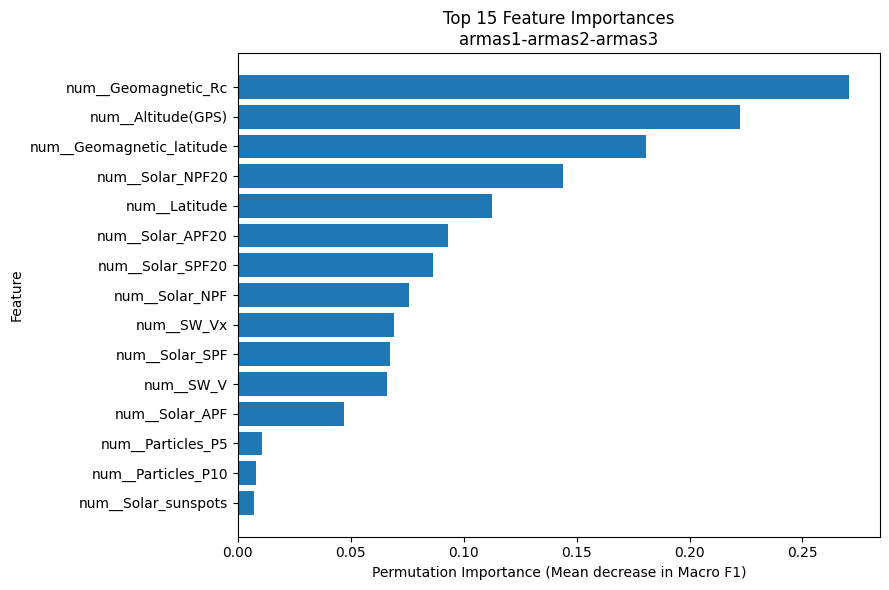


FEATURE IMPORTANCE ROTATION: Train=armas1, Validation=armas3, Test=armas2
Best C for importance analysis: 0.204336

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.291185        0.002654
3          num__Altitude(GPS)         0.201535        0.003133
4   num__Geomagnetic_latitude         0.106148        0.001291
0               num__Latitude         0.045024        0.001843
25                  num__SW_V         0.041559        0.001427
26                 num__SW_Vx         0.037591        0.001314
40           num__Solar_NPF20         0.036258        0.001667
41           num__Solar_SPF20         0.028341        0.001172
39             num__Solar_APF         0.024189        0.000911
42           num__Solar_APF20         0.018612        0.000783
38             num__Solar_SPF         0.017151        0.001238
19        num__Particles_P100         0.016127        0.000736
37             num__Solar_NPF         0

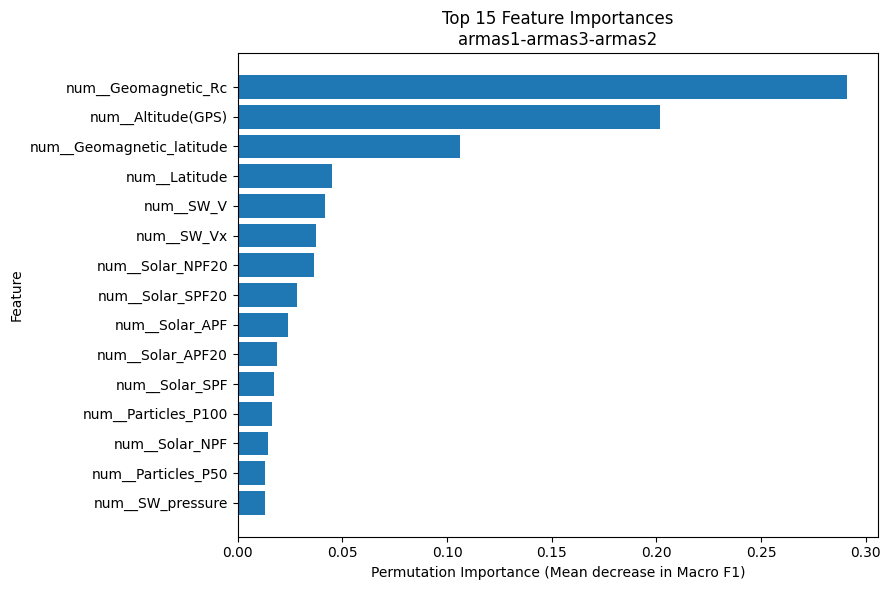


FEATURE IMPORTANCE ROTATION: Train=armas2, Validation=armas1, Test=armas3
Best C for importance analysis: 0.204336

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.270652        0.002205
3          num__Altitude(GPS)         0.221725        0.001522
4   num__Geomagnetic_latitude         0.141773        0.002508
40           num__Solar_NPF20         0.104681        0.002656
0               num__Latitude         0.069657        0.002773
42           num__Solar_APF20         0.056563        0.001756
41           num__Solar_SPF20         0.045263        0.001874
37             num__Solar_NPF         0.028878        0.002004
38             num__Solar_SPF         0.024664        0.001473
26                 num__SW_Vx         0.022580        0.001081
15          num__Particles_P5         0.011084        0.000342
39             num__Solar_APF         0.009559        0.001078
16         num__Particles_P10         0

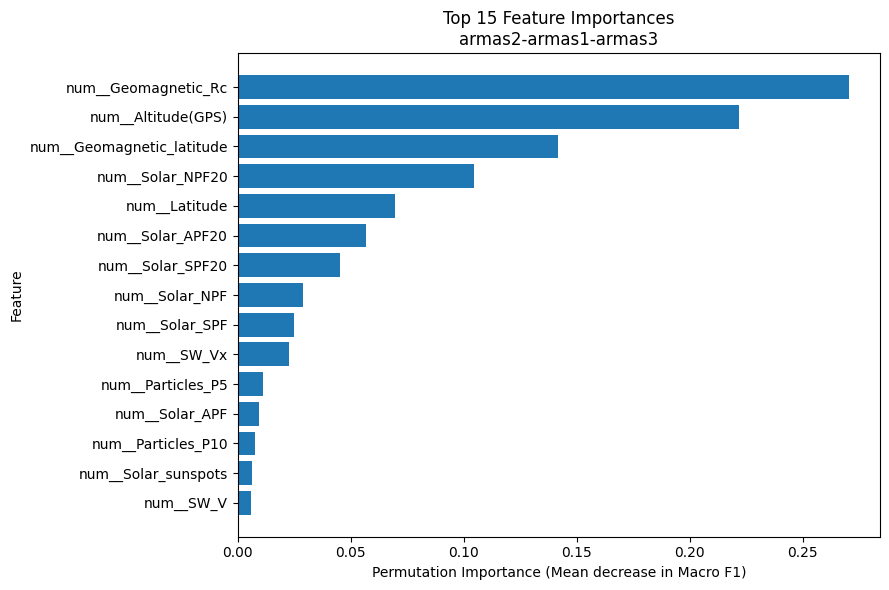


FEATURE IMPORTANCE ROTATION: Train=armas2, Validation=armas3, Test=armas1
Best C for importance analysis: 0.030392

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.270220        0.002838
3          num__Altitude(GPS)         0.204135        0.002039
4   num__Geomagnetic_latitude         0.034676        0.001631
40           num__Solar_NPF20         0.025625        0.001385
41           num__Solar_SPF20         0.010863        0.001186
19        num__Particles_P100         0.007455        0.000683
11               num__NM_SOPO         0.004902        0.001288
17         num__Particles_P30         0.004069        0.001016
0               num__Latitude         0.004017        0.001092
10               num__NM_THUL         0.003241        0.000904
38             num__Solar_SPF         0.003139        0.000931
37             num__Solar_NPF         0.002961        0.001026
25                  num__SW_V         0

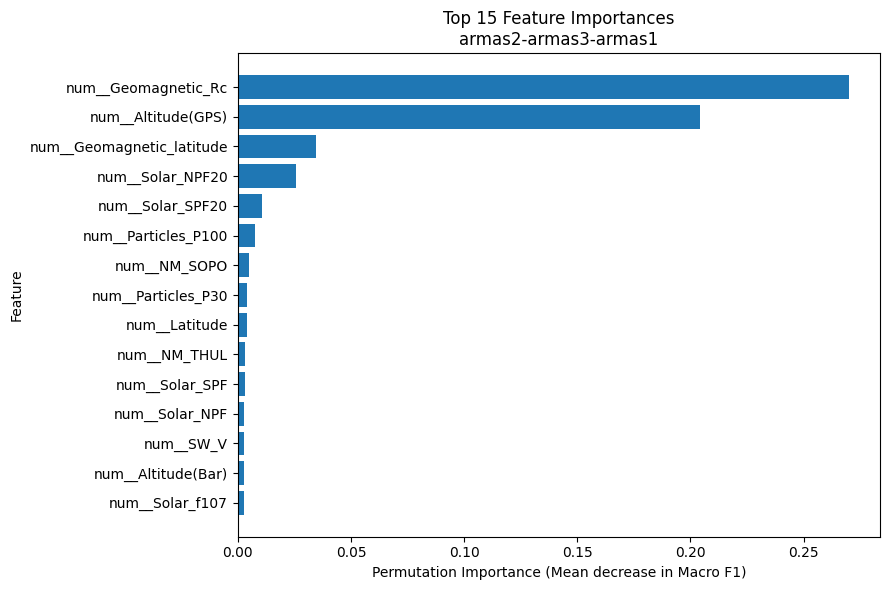


FEATURE IMPORTANCE ROTATION: Train=armas3, Validation=armas1, Test=armas2
Best C for importance analysis: 0.204336

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.291356        0.002659
3          num__Altitude(GPS)         0.201657        0.003093
4   num__Geomagnetic_latitude         0.106298        0.001335
0               num__Latitude         0.045323        0.001835
25                  num__SW_V         0.041739        0.001491
26                 num__SW_Vx         0.037567        0.001448
40           num__Solar_NPF20         0.036261        0.001648
41           num__Solar_SPF20         0.028460        0.001196
39             num__Solar_APF         0.024246        0.000915
42           num__Solar_APF20         0.018664        0.000808
38             num__Solar_SPF         0.017287        0.001233
19        num__Particles_P100         0.016258        0.000774
37             num__Solar_NPF         0

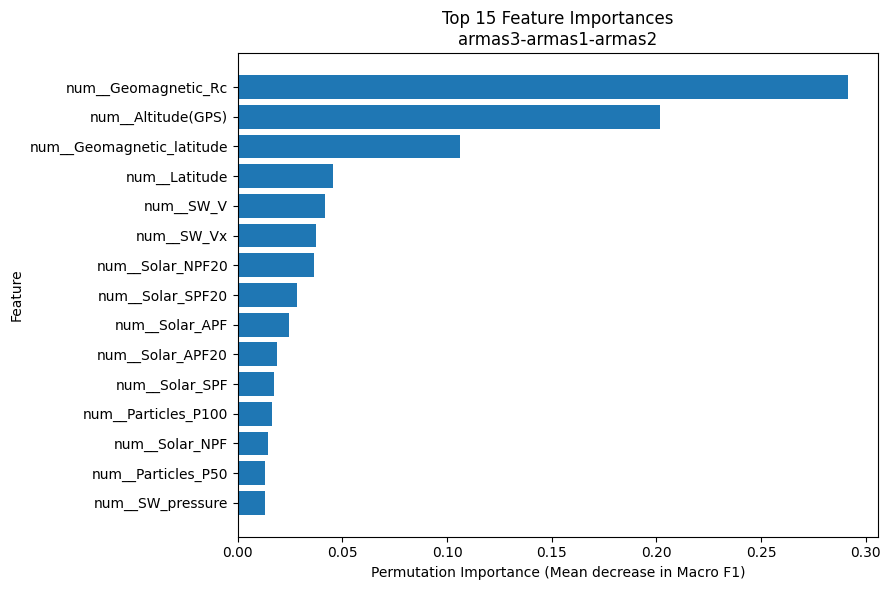


FEATURE IMPORTANCE ROTATION: Train=armas3, Validation=armas2, Test=armas1
Best C for importance analysis: 0.385662

Top feature importances:
                      feature  importance_mean  importance_std
6         num__Geomagnetic_Rc         0.265967        0.002945
3          num__Altitude(GPS)         0.211755        0.002106
4   num__Geomagnetic_latitude         0.164403        0.002434
0               num__Latitude         0.100200        0.001808
40           num__Solar_NPF20         0.081261        0.001497
42           num__Solar_APF20         0.043783        0.001595
26                 num__SW_Vx         0.038107        0.001423
41           num__Solar_SPF20         0.034957        0.001503
25                  num__SW_V         0.033587        0.001841
38             num__Solar_SPF         0.024009        0.001453
37             num__Solar_NPF         0.022991        0.001623
39             num__Solar_APF         0.011711        0.000713
2          num__Altitude(Bar)         0

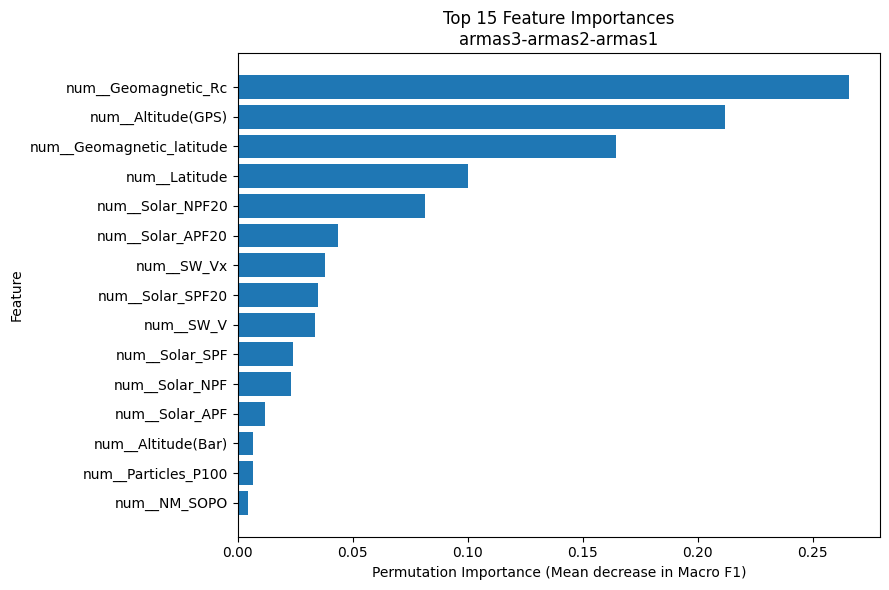


COMBINED FEATURE IMPORTANCES FROM ALL ROTATIONS
                     feature  importance_mean  importance_std train_set  \
0        num__Geomagnetic_Rc         0.270801        0.002208    armas1   
1         num__Altitude(GPS)         0.222280        0.001777    armas1   
2  num__Geomagnetic_latitude         0.180870        0.002142    armas1   
3           num__Solar_NPF20         0.144047        0.002126    armas1   
4              num__Latitude         0.112565        0.002233    armas1   

  valid_set test_set              rotation  
0    armas2   armas3  armas1-armas2-armas3  
1    armas2   armas3  armas1-armas2-armas3  
2    armas2   armas3  armas1-armas2-armas3  
3    armas2   armas3  armas1-armas2-armas3  
4    armas2   armas3  armas1-armas2-armas3  

AVERAGE FEATURE IMPORTANCE ACROSS ALL ROTATIONS
                      feature  avg_importance_mean  std_importance_mean
3         num__Geomagnetic_Rc             0.276697             0.011429
1          num__Altitude(GPS)        

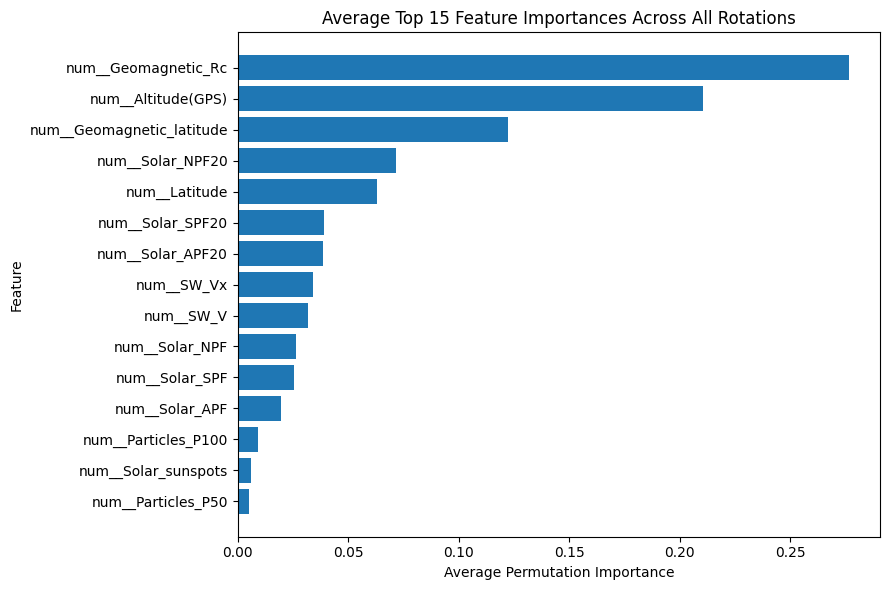


Saved:
- all_rotation_feature_importances.csv
- average_feature_importance_across_rotations.csv


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# =========================================================
# FEATURE IMPORTANCE ACROSS ALL ROTATIONS
# USING PERMUTATION IMPORTANCE
# =========================================================

all_importance_dfs = []
top_n = 15   # number of top features to display in plots

for train_name, valid_name, test_name in rotations:

    print("\n" + "=" * 80)
    print(f"FEATURE IMPORTANCE ROTATION: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print("=" * 80)

    train_df = datasets[train_name].copy()
    valid_df = datasets[valid_name].copy()
    test_df = datasets[test_name].copy()

    X_train, y_train = split_xy(train_df)
    X_valid, y_valid = split_xy(valid_df)
    X_test, y_test = split_xy(test_df)

    # -----------------------------------------------------
    # Tune C on validation set
    # -----------------------------------------------------
    rotation_results = []

    for c in C_values:
        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                C=c,
                max_iter=2000,
                class_weight='balanced',
                solver='lbfgs'
            ))
        ])

        model.fit(X_train, y_train)
        y_valid_pred = model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred, average='macro')

        rotation_results.append({
            'C': c,
            'valid_f1_macro': valid_f1
        })

    rotation_df = pd.DataFrame(rotation_results).sort_values('valid_f1_macro', ascending=False)
    best_c = rotation_df.iloc[0]['C']

    print(f"Best C for importance analysis: {best_c:.6f}")

    # -----------------------------------------------------
    # Retrain final model on train + validation
    # -----------------------------------------------------
    X_train_final = pd.concat([X_train, X_valid], axis=0)
    y_train_final = pd.concat([y_train, y_valid], axis=0)

    final_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            C=best_c,
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs'
        ))
    ])

    final_model.fit(X_train_final, y_train_final)

    # -----------------------------------------------------
    # Get transformed feature names
    # -----------------------------------------------------
    feature_names = final_model.named_steps['prep'].get_feature_names_out()

    # -----------------------------------------------------
    # Compute permutation importance on TEST set
    # -----------------------------------------------------
    perm = permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring='f1_macro',
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
        'train_set': train_name,
        'valid_set': valid_name,
        'test_set': test_name,
        'rotation': f"{train_name}-{valid_name}-{test_name}"
    }).sort_values('importance_mean', ascending=False)

    all_importance_dfs.append(importance_df)

    # -----------------------------------------------------
    # Print top features for this rotation
    # -----------------------------------------------------
    print("\nTop feature importances:")
    print(importance_df[['feature', 'importance_mean', 'importance_std']].head(top_n))

    # -----------------------------------------------------
    # Plot top features for this rotation
    # -----------------------------------------------------
    top_features_df = importance_df.head(top_n).sort_values('importance_mean')

    plt.figure(figsize=(9, 6))
    plt.barh(top_features_df['feature'], top_features_df['importance_mean'])
    plt.xlabel('Permutation Importance (Mean decrease in Macro F1)')
    plt.ylabel('Feature')
    plt.title(f'Top {top_n} Feature Importances\n{train_name}-{valid_name}-{test_name}')
    plt.tight_layout()
    plt.show()

# =========================================================
# COMBINE ALL ROTATION IMPORTANCES
# =========================================================
all_importances_combined = pd.concat(all_importance_dfs, axis=0, ignore_index=True)

print("\n" + "=" * 80)
print("COMBINED FEATURE IMPORTANCES FROM ALL ROTATIONS")
print("=" * 80)
print(all_importances_combined.head())

# =========================================================
# AVERAGE IMPORTANCE ACROSS ROTATIONS
# =========================================================
avg_importance_df = (
    all_importances_combined
    .groupby('feature', as_index=False)
    .agg(
        avg_importance_mean=('importance_mean', 'mean'),
        std_importance_mean=('importance_mean', 'std')
    )
    .sort_values('avg_importance_mean', ascending=False)
)

print("\n" + "=" * 80)
print("AVERAGE FEATURE IMPORTANCE ACROSS ALL ROTATIONS")
print("=" * 80)
print(avg_importance_df.head(30))

# =========================================================
# PLOT AVERAGE TOP FEATURES
# =========================================================
avg_top_features_df = avg_importance_df.head(top_n).sort_values('avg_importance_mean')

plt.figure(figsize=(9, 6))
plt.barh(avg_top_features_df['feature'], avg_top_features_df['avg_importance_mean'])
plt.xlabel('Average Permutation Importance')
plt.ylabel('Feature')
plt.title(f'Average Top {top_n} Feature Importances Across All Rotations')
plt.tight_layout()
plt.show()

# =========================================================
# OPTIONAL: SAVE RESULTS
# =========================================================
# all_importances_combined.to_csv("all_rotation_feature_importances.csv", index=False)
# avg_importance_df.to_csv("average_feature_importance_across_rotations.csv", index=False)

print("\nSaved:")
print("- all_rotation_feature_importances.csv")
print("- average_feature_importance_across_rotations.csv")


SHAP ROTATION: Train=armas1, Validation=armas2, Test=armas3
Best C selected for SHAP analysis: 1.373824

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
40           num__Solar_NPF20         1.471492    armas1    armas2   armas3   
6         num__Geomagnetic_Rc         1.463821    armas1    armas2   armas3   
42           num__Solar_APF20         1.255552    armas1    armas2   armas3   
3          num__Altitude(GPS)         1.165865    armas1    armas2   armas3   
4   num__Geomagnetic_latitude         0.975058    armas1    armas2   armas3   
41           num__Solar_SPF20         0.863896    armas1    armas2   armas3   
0               num__Latitude         0.767609    armas1    armas2   armas3   
25                  num__SW_V         0.515187    armas1    armas2   armas3   
37             num__Solar_NPF         0.497614    armas1    armas2   armas3   
26                 num__SW_Vx         0.493926    armas1    armas2 

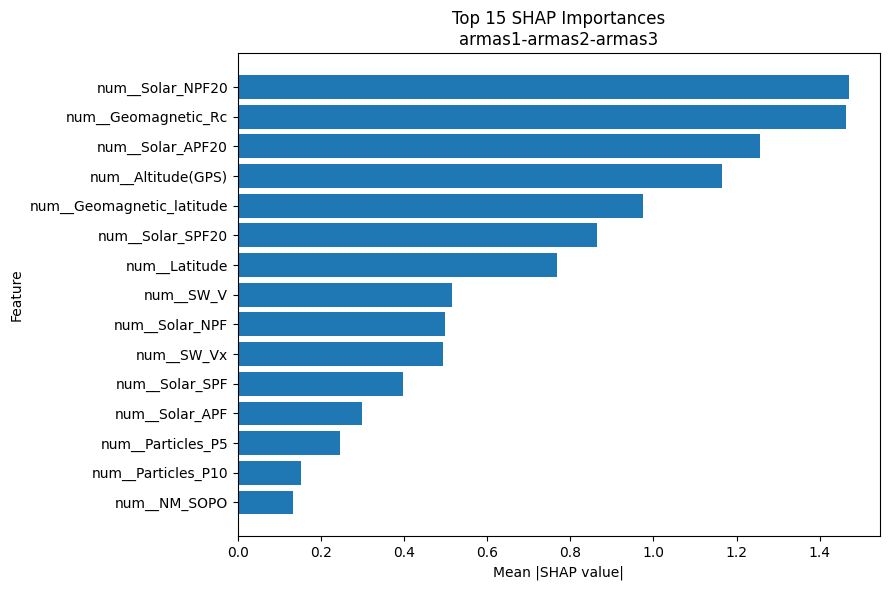


SHAP ROTATION: Train=armas1, Validation=armas3, Test=armas2
Best C selected for SHAP analysis: 0.204336

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
6         num__Geomagnetic_Rc         1.704261    armas1    armas3   armas2   
3          num__Altitude(GPS)         1.189462    armas1    armas3   armas2   
4   num__Geomagnetic_latitude         0.607782    armas1    armas3   armas2   
0               num__Latitude         0.433202    armas1    armas3   armas2   
25                  num__SW_V         0.389837    armas1    armas3   armas2   
40           num__Solar_NPF20         0.298392    armas1    armas3   armas2   
26                 num__SW_Vx         0.248994    armas1    armas3   armas2   
39             num__Solar_APF         0.222103    armas1    armas3   armas2   
41           num__Solar_SPF20         0.209466    armas1    armas3   armas2   
42           num__Solar_APF20         0.191692    armas1    armas3 

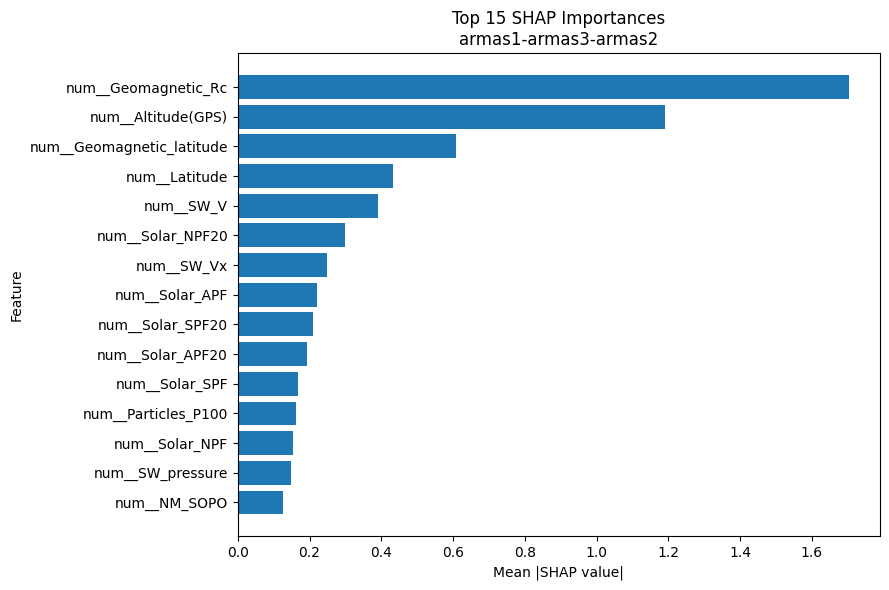


SHAP ROTATION: Train=armas2, Validation=armas1, Test=armas3
Best C selected for SHAP analysis: 0.204336

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
6         num__Geomagnetic_Rc         1.349025    armas2    armas1   armas3   
3          num__Altitude(GPS)         1.135044    armas2    armas1   armas3   
4   num__Geomagnetic_latitude         0.700024    armas2    armas1   armas3   
40           num__Solar_NPF20         0.667488    armas2    armas1   armas3   
42           num__Solar_APF20         0.508544    armas2    armas1   armas3   
0               num__Latitude         0.491346    armas2    armas1   armas3   
41           num__Solar_SPF20         0.354879    armas2    armas1   armas3   
37             num__Solar_NPF         0.230815    armas2    armas1   armas3   
25                  num__SW_V         0.196552    armas2    armas1   armas3   
26                 num__SW_Vx         0.184879    armas2    armas1 

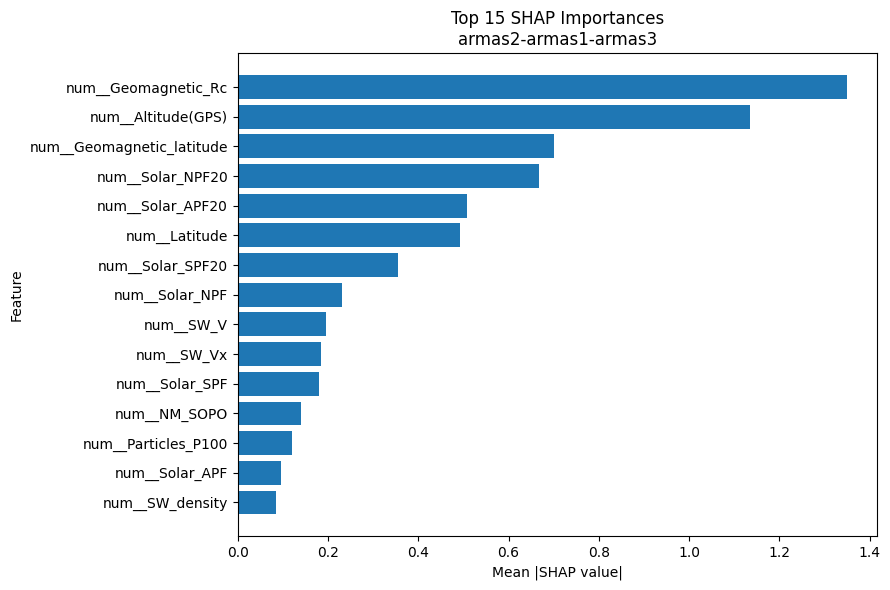


SHAP ROTATION: Train=armas2, Validation=armas3, Test=armas1
Best C selected for SHAP analysis: 0.030392

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
6         num__Geomagnetic_Rc         1.559414    armas2    armas3   armas1   
3          num__Altitude(GPS)         1.153737    armas2    armas3   armas1   
4   num__Geomagnetic_latitude         0.286470    armas2    armas3   armas1   
40           num__Solar_NPF20         0.179552    armas2    armas3   armas1   
7     num__Geomagnetic_Lshell         0.164786    armas2    armas3   armas1   
41           num__Solar_SPF20         0.141896    armas2    armas3   armas1   
37             num__Solar_NPF         0.139878    armas2    armas3   armas1   
11               num__NM_SOPO         0.121017    armas2    armas3   armas1   
36            num__Solar_f107         0.110055    armas2    armas3   armas1   
39             num__Solar_APF         0.107122    armas2    armas3 

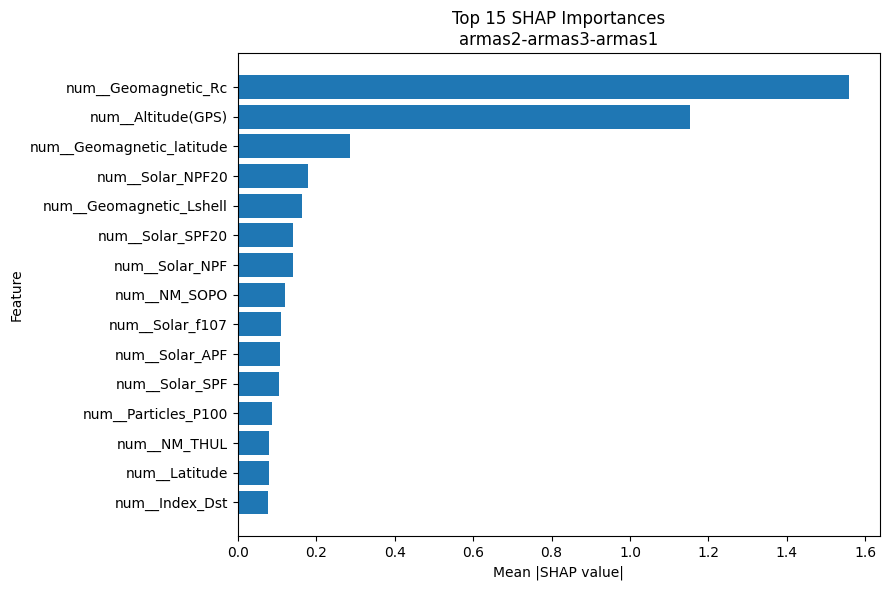


SHAP ROTATION: Train=armas3, Validation=armas1, Test=armas2
Best C selected for SHAP analysis: 0.204336

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
6         num__Geomagnetic_Rc         1.696224    armas3    armas1   armas2   
3          num__Altitude(GPS)         1.188202    armas3    armas1   armas2   
4   num__Geomagnetic_latitude         0.586113    armas3    armas1   armas2   
0               num__Latitude         0.418034    armas3    armas1   armas2   
25                  num__SW_V         0.389478    armas3    armas1   armas2   
40           num__Solar_NPF20         0.302493    armas3    armas1   armas2   
26                 num__SW_Vx         0.248611    armas3    armas1   armas2   
39             num__Solar_APF         0.230034    armas3    armas1   armas2   
41           num__Solar_SPF20         0.209231    armas3    armas1   armas2   
42           num__Solar_APF20         0.198013    armas3    armas1 

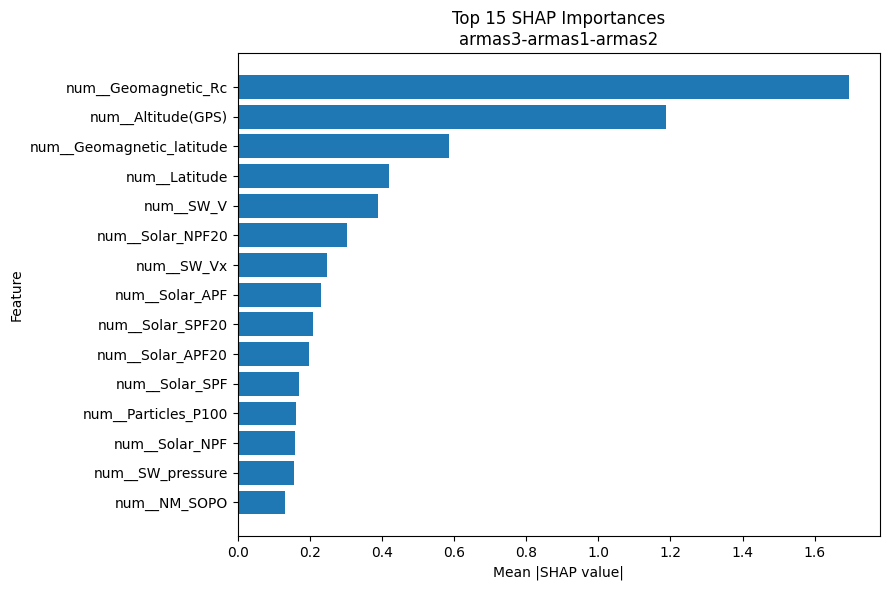


SHAP ROTATION: Train=armas3, Validation=armas2, Test=armas1
Best C selected for SHAP analysis: 0.385662

Top SHAP features for this rotation:
                      feature  shap_importance train_set valid_set test_set  \
6         num__Geomagnetic_Rc         1.818981    armas3    armas2   armas1   
3          num__Altitude(GPS)         1.291831    armas3    armas2   armas1   
4   num__Geomagnetic_latitude         0.901908    armas3    armas2   armas1   
0               num__Latitude         0.667847    armas3    armas2   armas1   
40           num__Solar_NPF20         0.534390    armas3    armas2   armas1   
42           num__Solar_APF20         0.397661    armas3    armas2   armas1   
41           num__Solar_SPF20         0.358877    armas3    armas2   armas1   
26                 num__SW_Vx         0.294797    armas3    armas2   armas1   
25                  num__SW_V         0.285482    armas3    armas2   armas1   
37             num__Solar_NPF         0.283165    armas3    armas2 

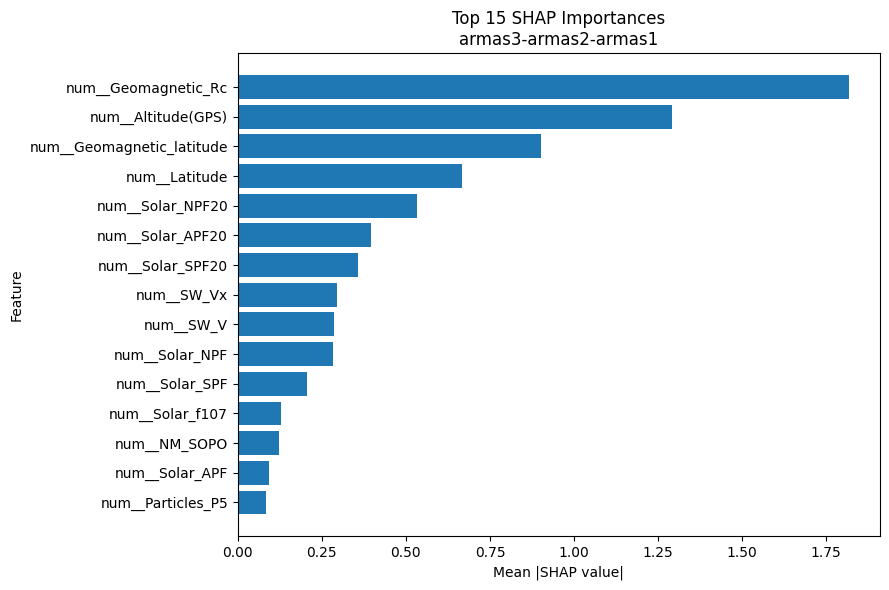


ALL ROTATION SHAP IMPORTANCES
                     feature  shap_importance train_set valid_set test_set  \
0           num__Solar_NPF20         1.471492    armas1    armas2   armas3   
1        num__Geomagnetic_Rc         1.463821    armas1    armas2   armas3   
2           num__Solar_APF20         1.255552    armas1    armas2   armas3   
3         num__Altitude(GPS)         1.165865    armas1    armas2   armas3   
4  num__Geomagnetic_latitude         0.975058    armas1    armas2   armas3   

               rotation  
0  armas1-armas2-armas3  
1  armas1-armas2-armas3  
2  armas1-armas2-armas3  
3  armas1-armas2-armas3  
4  armas1-armas2-armas3  

AVERAGE SHAP IMPORTANCE ACROSS ALL ROTATIONS
                       feature  avg_shap_importance  std_shap_importance
3          num__Geomagnetic_Rc             1.598621             0.173926
1           num__Altitude(GPS)             1.187357             0.055225
4    num__Geomagnetic_latitude             0.676226             0.247190
38    

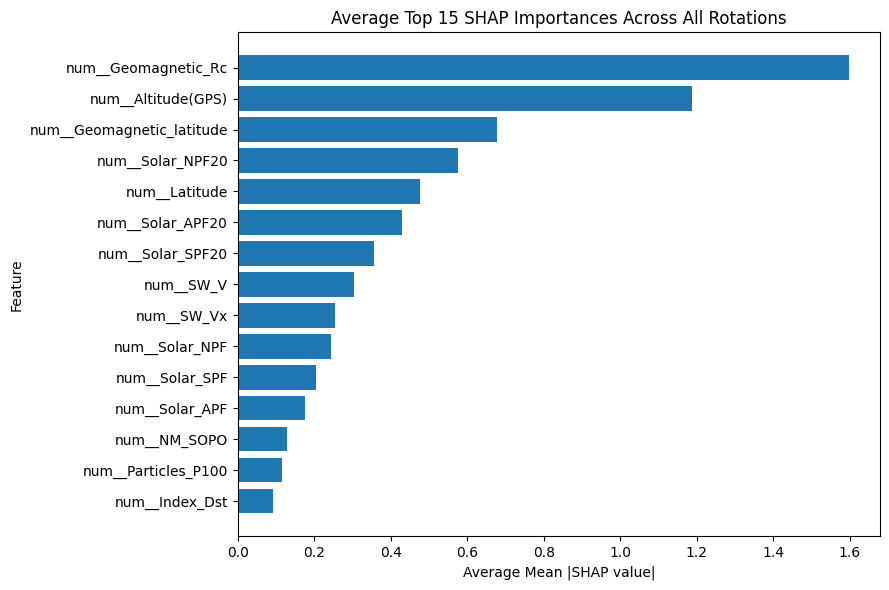


Saved files:
- all_rotation_shap_importance.csv
- average_shap_importance_across_rotations.csv


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# =========================================================
# SHAP IMPORTANCE ACROSS ALL ROTATIONS
# FOR MULTICLASS LOGISTIC REGRESSION
# =========================================================

top_n = 15
all_shap_dfs = []

for train_name, valid_name, test_name in rotations:

    print("\n" + "=" * 80)
    print(f"SHAP ROTATION: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print("=" * 80)

    train_df = datasets[train_name].copy()
    valid_df = datasets[valid_name].copy()
    test_df = datasets[test_name].copy()

    X_train, y_train = split_xy(train_df)
    X_valid, y_valid = split_xy(valid_df)
    X_test, y_test = split_xy(test_df)

    # -----------------------------------------------------
    # 1. Tune C on validation set
    # -----------------------------------------------------
    rotation_results = []

    for c in C_values:
        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                C=c,
                max_iter=2000,
                class_weight='balanced',
                solver='lbfgs'
            ))
        ])

        model.fit(X_train, y_train)
        y_valid_pred = model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred, average='macro')

        rotation_results.append({
            'C': c,
            'valid_f1_macro': valid_f1
        })

    rotation_df = pd.DataFrame(rotation_results).sort_values('valid_f1_macro', ascending=False)
    best_c = rotation_df.iloc[0]['C']

    print(f"Best C selected for SHAP analysis: {best_c:.6f}")

    # -----------------------------------------------------
    # 2. Retrain final model on train + validation
    # -----------------------------------------------------
    X_train_final = pd.concat([X_train, X_valid], axis=0)
    y_train_final = pd.concat([y_train, y_valid], axis=0)

    final_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            C=best_c,
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs'
        ))
    ])

    final_model.fit(X_train_final, y_train_final)

    # -----------------------------------------------------
    # 3. Transform features
    # -----------------------------------------------------
    X_train_final_trans = final_model.named_steps['prep'].transform(X_train_final)
    X_test_trans = final_model.named_steps['prep'].transform(X_test)
    feature_names = final_model.named_steps['prep'].get_feature_names_out()

    # Optional: convert sparse to dense if needed
    if hasattr(X_train_final_trans, "toarray"):
        X_train_final_trans = X_train_final_trans.toarray()
    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    # -----------------------------------------------------
    # 4. Use a smaller background sample for speed
    # -----------------------------------------------------
    background_size = min(200, X_train_final_trans.shape[0])
    test_sample_size = min(300, X_test_trans.shape[0])

    rng = np.random.default_rng(42)

    bg_idx = rng.choice(X_train_final_trans.shape[0], size=background_size, replace=False)
    test_idx = rng.choice(X_test_trans.shape[0], size=test_sample_size, replace=False)

    X_background = X_train_final_trans[bg_idx]
    X_test_sample = X_test_trans[test_idx]

    # -----------------------------------------------------
    # 5. SHAP explainer for linear multiclass logistic regression
    # -----------------------------------------------------
    clf = final_model.named_steps['clf']

    explainer = shap.LinearExplainer(clf, X_background)
    shap_values = explainer.shap_values(X_test_sample)

    # -----------------------------------------------------
    # 6. Handle multiclass SHAP output robustly
    # -----------------------------------------------------
    # Depending on SHAP version:
    # - shap_values may be a list of arrays [n_classes][n_samples, n_features]
    # - or a 3D array [n_samples, n_features, n_classes]
    # We convert everything to one array and then average abs SHAP.
    if isinstance(shap_values, list):
        # list of shape: [n_classes] each (n_samples, n_features)
        shap_array = np.stack(shap_values, axis=-1)   # (n_samples, n_features, n_classes)
    else:
        shap_array = np.array(shap_values)

        # Some versions may return (n_classes, n_samples, n_features)
        if shap_array.ndim == 3 and shap_array.shape[0] == len(clf.classes_):
            shap_array = np.moveaxis(shap_array, 0, -1)  # -> (n_samples, n_features, n_classes)

    # -----------------------------------------------------
    # 7. Aggregate SHAP importance
    # -----------------------------------------------------
    # Mean absolute SHAP across samples and classes
    if shap_array.ndim == 3:
        shap_importance = np.mean(np.abs(shap_array), axis=(0, 2))
    elif shap_array.ndim == 2:
        shap_importance = np.mean(np.abs(shap_array), axis=0)
    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance,
        'train_set': train_name,
        'valid_set': valid_name,
        'test_set': test_name,
        'rotation': f"{train_name}-{valid_name}-{test_name}"
    }).sort_values('shap_importance', ascending=False)

    all_shap_dfs.append(shap_df)

    print("\nTop SHAP features for this rotation:")
    print(shap_df.head(top_n))

    # -----------------------------------------------------
    # 8. Plot top SHAP importance for this rotation
    # -----------------------------------------------------
    top_shap_df = shap_df.head(top_n).sort_values('shap_importance')

    plt.figure(figsize=(9, 6))
    plt.barh(top_shap_df['feature'], top_shap_df['shap_importance'])
    plt.xlabel('Mean |SHAP value|')
    plt.ylabel('Feature')
    plt.title(f'Top {top_n} SHAP Importances\n{train_name}-{valid_name}-{test_name}')
    plt.tight_layout()
    plt.show()

# =========================================================
# 9. Combine all SHAP results
# =========================================================
all_shap_combined = pd.concat(all_shap_dfs, axis=0, ignore_index=True)

print("\n" + "=" * 80)
print("ALL ROTATION SHAP IMPORTANCES")
print("=" * 80)
print(all_shap_combined.head())

# =========================================================
# 10. Average SHAP importance across rotations
# =========================================================
avg_shap_df = (
    all_shap_combined
    .groupby('feature', as_index=False)
    .agg(
        avg_shap_importance=('shap_importance', 'mean'),
        std_shap_importance=('shap_importance', 'std')
    )
    .sort_values('avg_shap_importance', ascending=False)
)

print("\n" + "=" * 80)
print("AVERAGE SHAP IMPORTANCE ACROSS ALL ROTATIONS")
print("=" * 80)
print(avg_shap_df.head(30))

# =========================================================
# 11. Plot average SHAP importance
# =========================================================
avg_top_shap_df = avg_shap_df.head(top_n).sort_values('avg_shap_importance')

plt.figure(figsize=(9, 6))
plt.barh(avg_top_shap_df['feature'], avg_top_shap_df['avg_shap_importance'])
plt.xlabel('Average Mean |SHAP value|')
plt.ylabel('Feature')
plt.title(f'Average Top {top_n} SHAP Importances Across All Rotations')
plt.tight_layout()
plt.show()

# =========================================================
# 12. Save SHAP results
# =========================================================
# all_shap_combined.to_csv("all_rotation_shap_importance.csv", index=False)
# avg_shap_df.to_csv("average_shap_importance_across_rotations.csv", index=False)

print("\nSaved files:")
print("- all_rotation_shap_importance.csv")
print("- average_shap_importance_across_rotations.csv")


CLASS-SPECIFIC SHAP ROTATION: Train=armas1, Validation=armas2, Test=armas3
Best C selected: 1.373824

Top SHAP features for class 0 in rotation armas1-armas2-armas3:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         1.965652    armas1    armas2   
3          num__Altitude(GPS)      0         1.704947    armas1    armas2   
4   num__Geomagnetic_latitude      0         1.421731    armas1    armas2   
40           num__Solar_NPF20      0         1.212615    armas1    armas2   
0               num__Latitude      0         1.093382    armas1    armas2   
42           num__Solar_APF20      0         0.997409    armas1    armas2   
41           num__Solar_SPF20      0         0.644831    armas1    armas2   
25                  num__SW_V      0         0.514436    armas1    armas2   
26                 num__SW_Vx      0         0.481292    armas1    armas2   
15          num__Particles_P5      0         0.368900    armas1

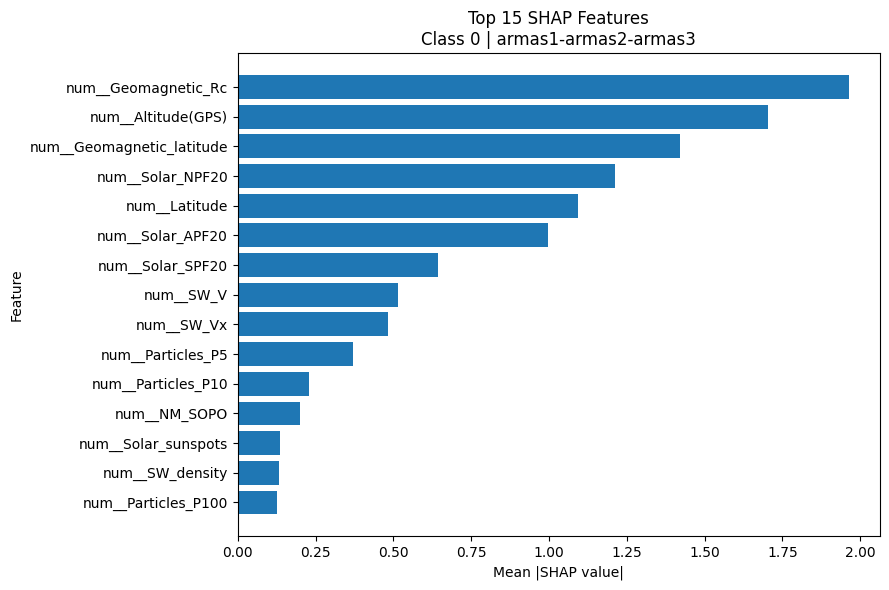


Top SHAP features for class 1 in rotation armas1-armas2-armas3:
                feature  class  shap_importance train_set valid_set test_set  \
40     num__Solar_NPF20      1         2.207238    armas1    armas2   armas3   
42     num__Solar_APF20      1         1.883327    armas1    armas2   armas3   
41     num__Solar_SPF20      1         1.295845    armas1    armas2   armas3   
37       num__Solar_NPF      1         0.620952    armas1    armas2   armas3   
38       num__Solar_SPF      1         0.502285    armas1    armas2   armas3   
39       num__Solar_APF      1         0.449445    armas1    armas2   armas3   
26           num__SW_Vx      1         0.259597    armas1    armas2   armas3   
25            num__SW_V      1         0.258345    armas1    armas2   armas3   
6   num__Geomagnetic_Rc      1         0.230079    armas1    armas2   armas3   
15    num__Particles_P5      1         0.128115    armas1    armas2   armas3   
36      num__Solar_f107      1         0.126527    arma

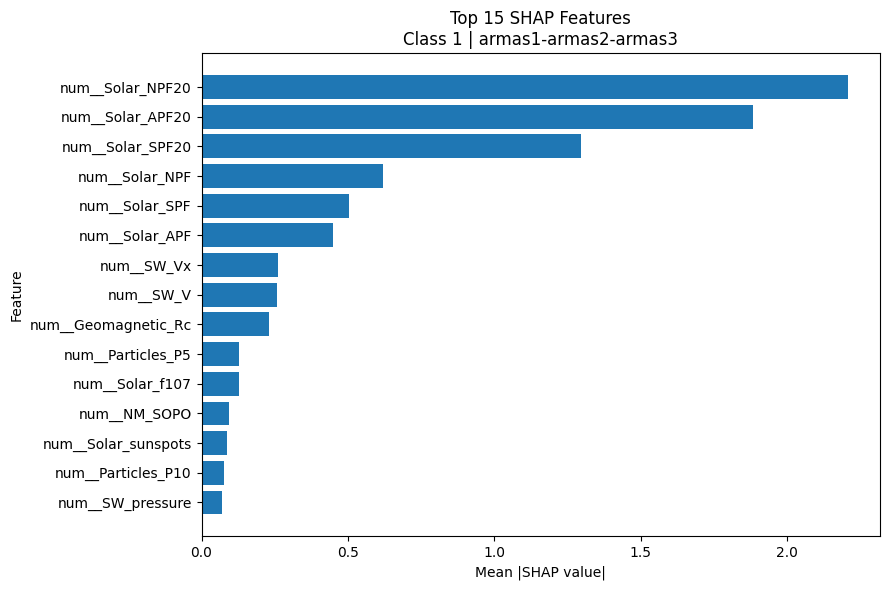


Top SHAP features for class 2 in rotation armas1-armas2-armas3:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.195731    armas1    armas2   
3          num__Altitude(GPS)      2         1.748798    armas1    armas2   
4   num__Geomagnetic_latitude      2         1.462587    armas1    armas2   
0               num__Latitude      2         1.151414    armas1    armas2   
40           num__Solar_NPF20      2         0.994623    armas1    armas2   
42           num__Solar_APF20      2         0.885919    armas1    armas2   
25                  num__SW_V      2         0.772781    armas1    armas2   
37             num__Solar_NPF      2         0.746421    armas1    armas2   
26                 num__SW_Vx      2         0.740890    armas1    armas2   
41           num__Solar_SPF20      2         0.651014    armas1    armas2   
38             num__Solar_SPF      2         0.597643    armas1    armas2   
39         

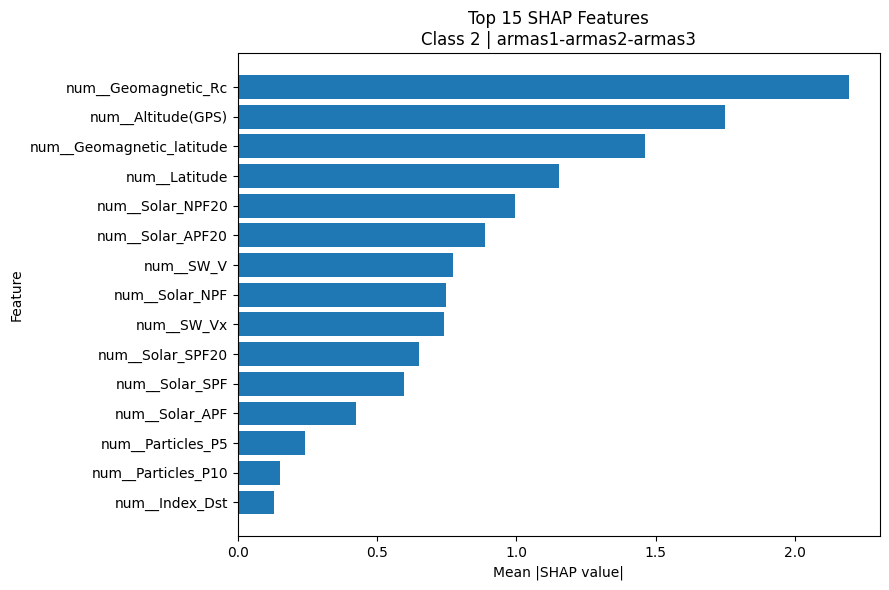


CLASS-SPECIFIC SHAP ROTATION: Train=armas1, Validation=armas3, Test=armas2
Best C selected: 0.204336

Top SHAP features for class 0 in rotation armas1-armas3-armas2:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         2.316955    armas1    armas3   
3          num__Altitude(GPS)      0         1.638134    armas1    armas3   
4   num__Geomagnetic_latitude      0         0.911673    armas1    armas3   
0               num__Latitude      0         0.649803    armas1    armas3   
25                  num__SW_V      0         0.584756    armas1    armas3   
26                 num__SW_Vx      0         0.355685    armas1    armas3   
39             num__Solar_APF      0         0.333155    armas1    armas3   
19        num__Particles_P100      0         0.244510    armas1    armas3   
31           num__SW_pressure      0         0.222825    armas1    armas3   
40           num__Solar_NPF20      0         0.219136    armas1

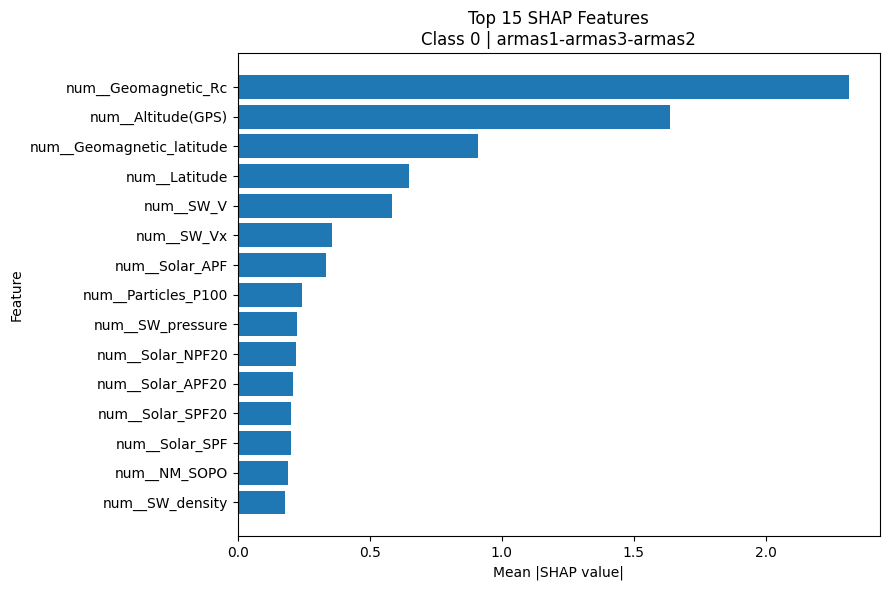


Top SHAP features for class 1 in rotation armas1-armas3-armas2:
                      feature  class  shap_importance train_set valid_set  \
25                  num__SW_V      1         0.429170    armas1    armas3   
26                 num__SW_Vx      1         0.373490    armas1    armas3   
38             num__Solar_SPF      1         0.251150    armas1    armas3   
6         num__Geomagnetic_Rc      1         0.239438    armas1    armas3   
37             num__Solar_NPF      1         0.231554    armas1    armas3   
40           num__Solar_NPF20      1         0.228452    armas1    armas3   
0               num__Latitude      1         0.169138    armas1    armas3   
4   num__Geomagnetic_latitude      1         0.153714    armas1    armas3   
3          num__Altitude(GPS)      1         0.146059    armas1    armas3   
18         num__Particles_P50      1         0.132542    armas1    armas3   
19        num__Particles_P100      1         0.132429    armas1    armas3   
41         

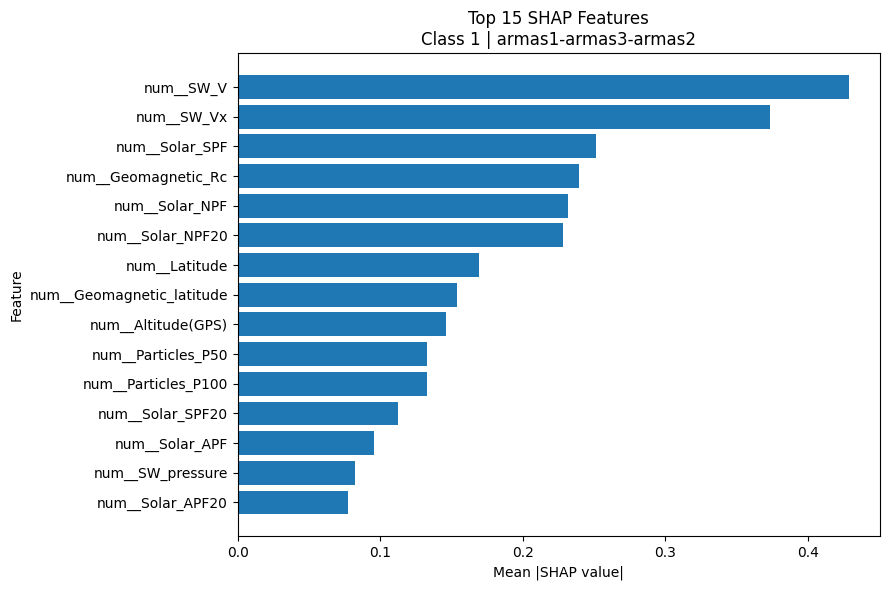


Top SHAP features for class 2 in rotation armas1-armas3-armas2:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.556392    armas1    armas3   
3          num__Altitude(GPS)      2         1.784193    armas1    armas3   
4   num__Geomagnetic_latitude      2         0.757958    armas1    armas3   
0               num__Latitude      2         0.480664    armas1    armas3   
40           num__Solar_NPF20      2         0.447589    armas1    armas3   
41           num__Solar_SPF20      2         0.314198    armas1    armas3   
42           num__Solar_APF20      2         0.287538    armas1    armas3   
39             num__Solar_APF      2         0.237634    armas1    armas3   
33             num__Index_Dst      2         0.164347    armas1    armas3   
25                  num__SW_V      2         0.155587    armas1    armas3   
31           num__SW_pressure      2         0.140550    armas1    armas3   
11         

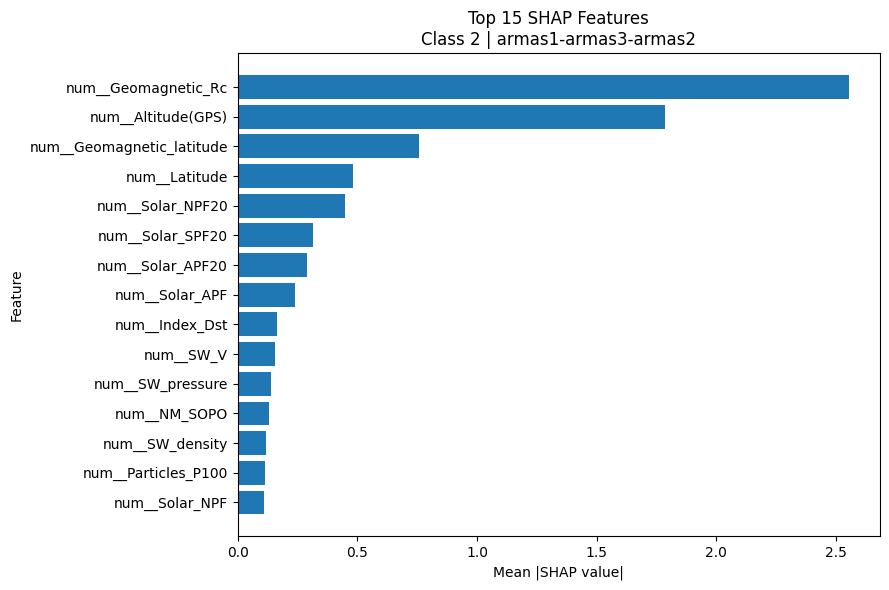


CLASS-SPECIFIC SHAP ROTATION: Train=armas2, Validation=armas1, Test=armas3
Best C selected: 0.204336

Top SHAP features for class 0 in rotation armas2-armas1-armas3:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         1.804482    armas2    armas1   
3          num__Altitude(GPS)      0         1.643481    armas2    armas1   
4   num__Geomagnetic_latitude      0         0.997603    armas2    armas1   
0               num__Latitude      0         0.671726    armas2    armas1   
40           num__Solar_NPF20      0         0.580224    armas2    armas1   
42           num__Solar_APF20      0         0.404638    armas2    armas1   
41           num__Solar_SPF20      0         0.239324    armas2    armas1   
11               num__NM_SOPO      0         0.208739    armas2    armas1   
25                  num__SW_V      0         0.193312    armas2    armas1   
19        num__Particles_P100      0         0.179490    armas2

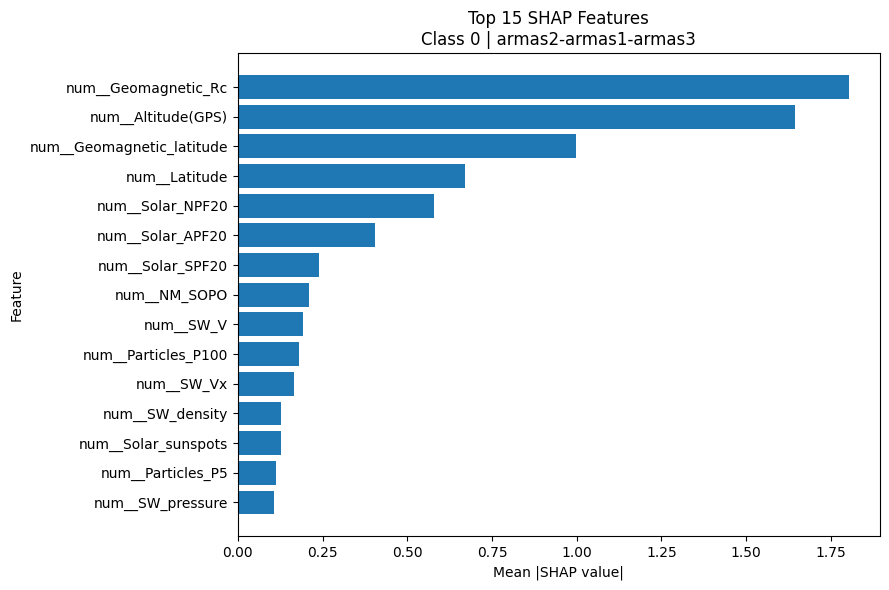


Top SHAP features for class 1 in rotation armas2-armas1-armas3:
                feature  class  shap_importance train_set valid_set test_set  \
40     num__Solar_NPF20      1         1.001232    armas2    armas1   armas3   
42     num__Solar_APF20      1         0.762816    armas2    armas1   armas3   
41     num__Solar_SPF20      1         0.532318    armas2    armas1   armas3   
37       num__Solar_NPF      1         0.269320    armas2    armas1   armas3   
6   num__Geomagnetic_Rc      1         0.219056    armas2    armas1   armas3   
38       num__Solar_SPF      1         0.195562    armas2    armas1   armas3   
39       num__Solar_APF      1         0.142784    armas2    armas1   armas3   
36      num__Solar_f107      1         0.119383    armas2    armas1   armas3   
26           num__SW_Vx      1         0.110000    armas2    armas1   armas3   
11         num__NM_SOPO      1         0.103874    armas2    armas1   armas3   
25            num__SW_V      1         0.101516    arma

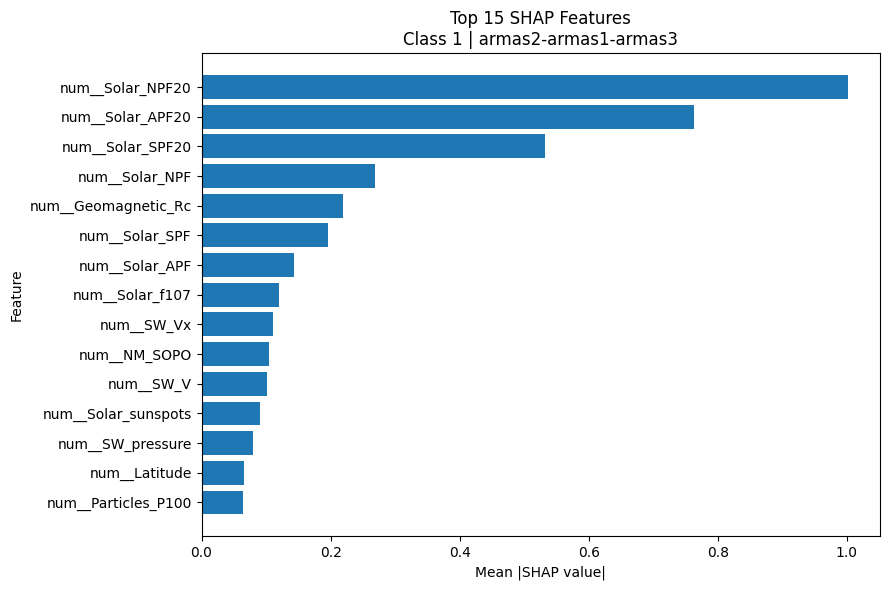


Top SHAP features for class 2 in rotation armas2-armas1-armas3:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.023538    armas2    armas1   
3          num__Altitude(GPS)      2         1.702566    armas2    armas1   
4   num__Geomagnetic_latitude      2         1.050036    armas2    armas1   
0               num__Latitude      2         0.737019    armas2    armas1   
40           num__Solar_NPF20      2         0.421008    armas2    armas1   
42           num__Solar_APF20      2         0.358178    armas2    armas1   
37             num__Solar_NPF      2         0.346223    armas2    armas1   
25                  num__SW_V      2         0.294828    armas2    armas1   
41           num__Solar_SPF20      2         0.292995    armas2    armas1   
26                 num__SW_Vx      2         0.277318    armas2    armas1   
38             num__Solar_SPF      2         0.269295    armas2    armas1   
33         

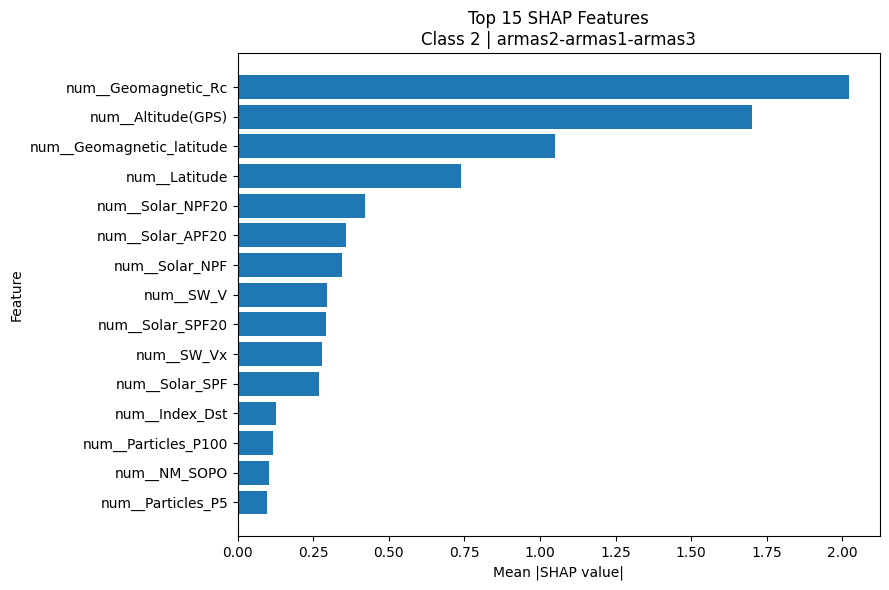


CLASS-SPECIFIC SHAP ROTATION: Train=armas2, Validation=armas3, Test=armas1
Best C selected: 0.030392

Top SHAP features for class 0 in rotation armas2-armas3-armas1:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         2.086212    armas2    armas3   
3          num__Altitude(GPS)      0         1.670018    armas2    armas3   
4   num__Geomagnetic_latitude      0         0.429705    armas2    armas3   
7     num__Geomagnetic_Lshell      0         0.247178    armas2    armas3   
11               num__NM_SOPO      0         0.181526    armas2    armas3   
19        num__Particles_P100      0         0.131645    armas2    armas3   
40           num__Solar_NPF20      0         0.121822    armas2    armas3   
10               num__NM_THUL      0         0.121179    armas2    armas3   
0               num__Latitude      0         0.118680    armas2    armas3   
39             num__Solar_APF      0         0.108314    armas2

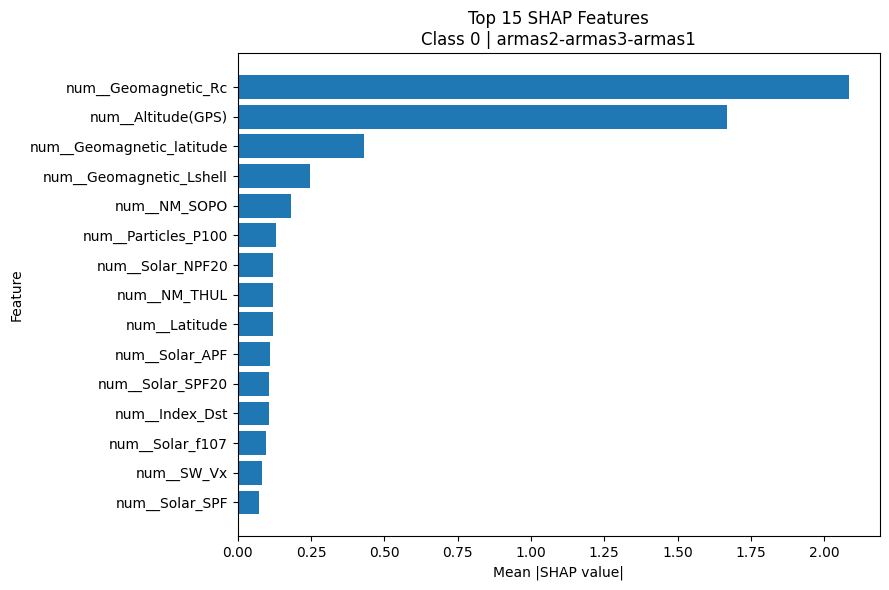


Top SHAP features for class 1 in rotation armas2-armas3-armas1:
                    feature  class  shap_importance train_set valid_set  \
40         num__Solar_NPF20      1         0.269328    armas2    armas3   
6       num__Geomagnetic_Rc      1         0.252910    armas2    armas3   
37           num__Solar_NPF      1         0.142332    armas2    armas3   
7   num__Geomagnetic_Lshell      1         0.122108    armas2    armas3   
41         num__Solar_SPF20      1         0.104841    armas2    armas3   
38           num__Solar_SPF      1         0.085704    armas2    armas3   
25                num__SW_V      1         0.075538    armas2    armas3   
36          num__Solar_f107      1         0.068063    armas2    armas3   
3        num__Altitude(GPS)      1         0.060588    armas2    armas3   
31         num__SW_pressure      1         0.058006    armas2    armas3   
39           num__Solar_APF      1         0.052369    armas2    armas3   
29          num__SW_density      1 

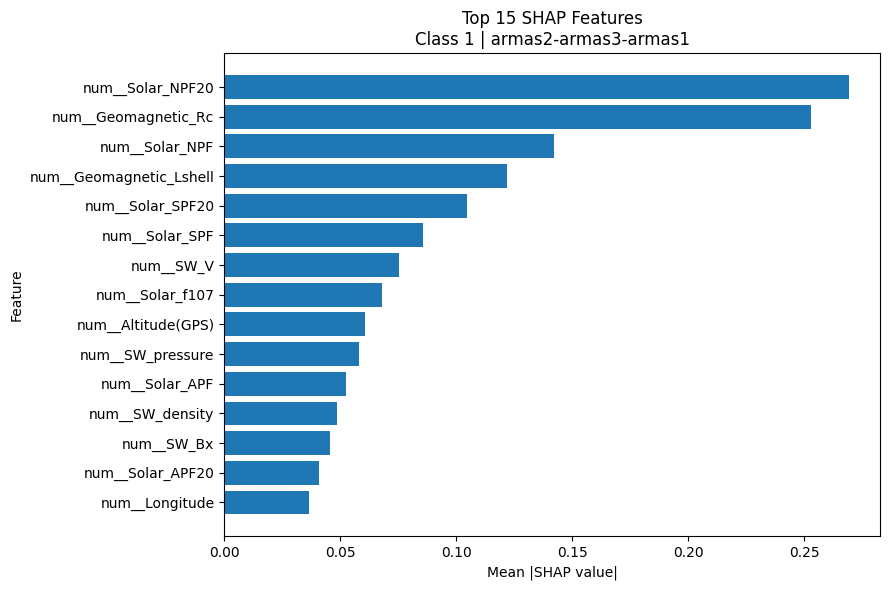


Top SHAP features for class 2 in rotation armas2-armas3-armas1:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.339122    armas2    armas3   
3          num__Altitude(GPS)      2         1.730605    armas2    armas3   
4   num__Geomagnetic_latitude      2         0.401284    armas2    armas3   
41           num__Solar_SPF20      2         0.212844    armas2    armas3   
37             num__Solar_NPF      2         0.209816    armas2    armas3   
36            num__Solar_f107      2         0.165083    armas2    armas3   
39             num__Solar_APF      2         0.160683    armas2    armas3   
38             num__Solar_SPF      2         0.159274    armas2    armas3   
11               num__NM_SOPO      2         0.155987    armas2    armas3   
40           num__Solar_NPF20      2         0.147506    armas2    armas3   
7     num__Geomagnetic_Lshell      2         0.125070    armas2    armas3   
33         

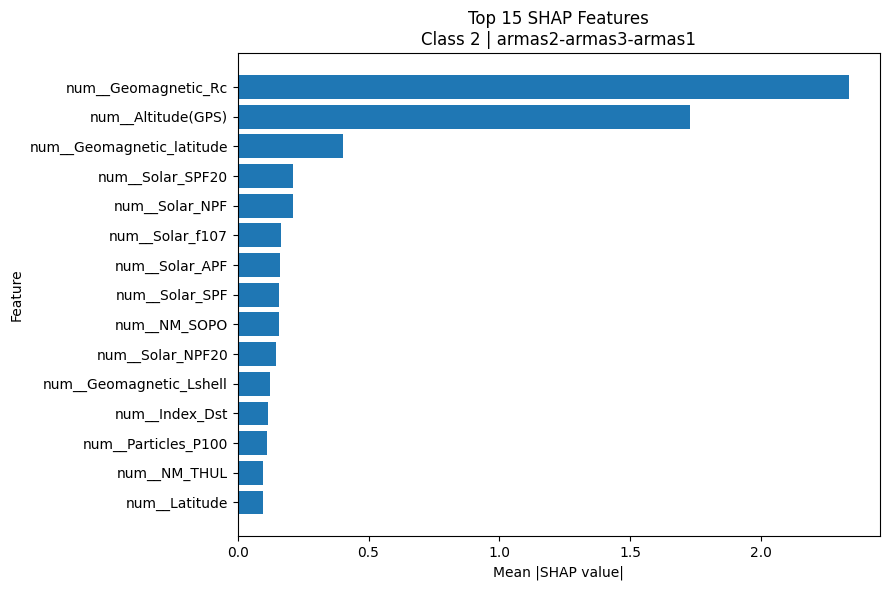


CLASS-SPECIFIC SHAP ROTATION: Train=armas3, Validation=armas1, Test=armas2
Best C selected: 0.204336

Top SHAP features for class 0 in rotation armas3-armas1-armas2:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         2.306237    armas3    armas1   
3          num__Altitude(GPS)      0         1.636143    armas3    armas1   
4   num__Geomagnetic_latitude      0         0.879169    armas3    armas1   
0               num__Latitude      0         0.627050    armas3    armas1   
25                  num__SW_V      0         0.584218    armas3    armas1   
26                 num__SW_Vx      0         0.355086    armas3    armas1   
39             num__Solar_APF      0         0.345050    armas3    armas1   
19        num__Particles_P100      0         0.243646    armas3    armas1   
31           num__SW_pressure      0         0.232821    armas3    armas1   
40           num__Solar_NPF20      0         0.221503    armas3

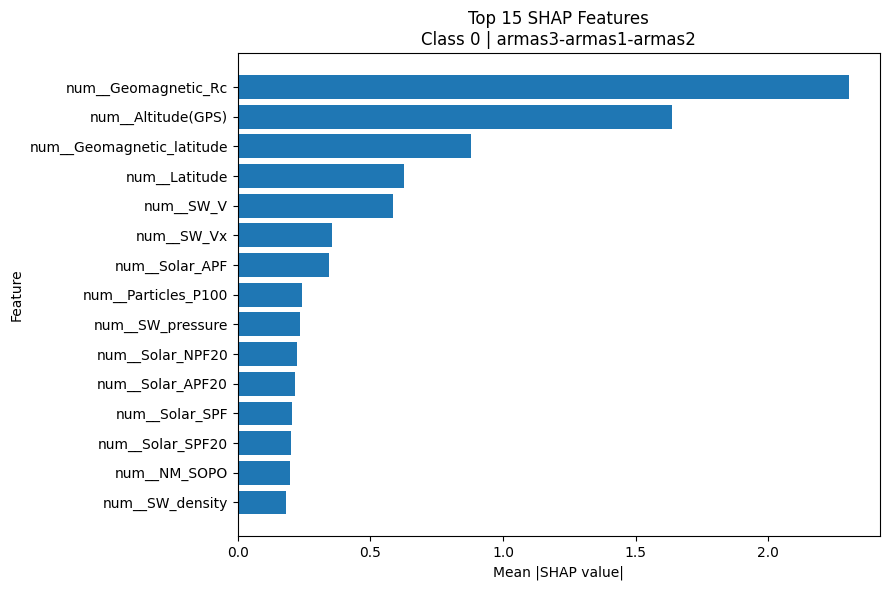


Top SHAP features for class 1 in rotation armas3-armas1-armas2:
                      feature  class  shap_importance train_set valid_set  \
25                  num__SW_V      1         0.428837    armas3    armas1   
26                 num__SW_Vx      1         0.372916    armas3    armas1   
38             num__Solar_SPF      1         0.256082    armas3    armas1   
6         num__Geomagnetic_Rc      1         0.238099    armas3    armas1   
37             num__Solar_NPF      1         0.237707    armas3    armas1   
40           num__Solar_NPF20      1         0.232237    armas3    armas1   
0               num__Latitude      1         0.163817    armas3    armas1   
4   num__Geomagnetic_latitude      1         0.149156    armas3    armas1   
3          num__Altitude(GPS)      1         0.146160    armas3    armas1   
19        num__Particles_P100      1         0.131919    armas3    armas1   
18         num__Particles_P50      1         0.129673    armas3    armas1   
41         

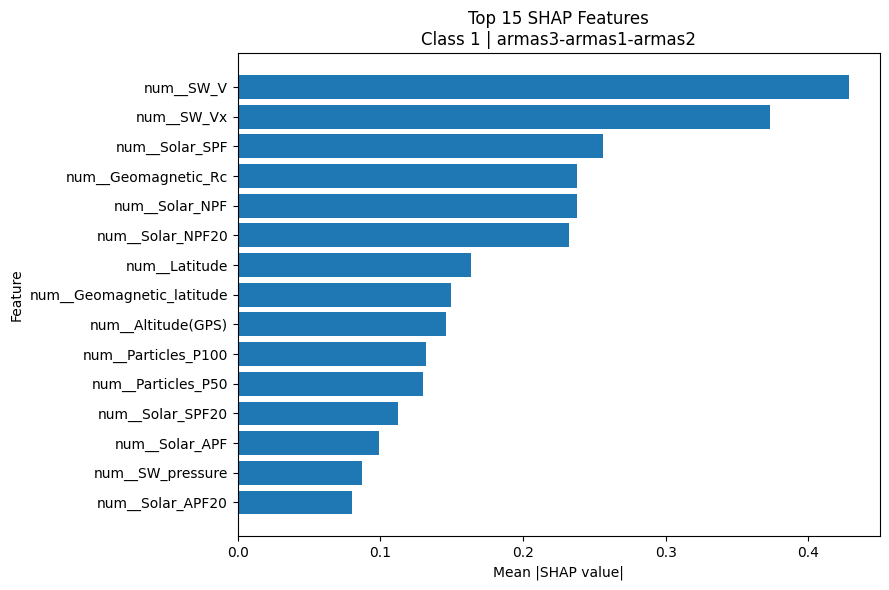


Top SHAP features for class 2 in rotation armas3-armas1-armas2:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.544336    armas3    armas1   
3          num__Altitude(GPS)      2         1.782303    armas3    armas1   
4   num__Geomagnetic_latitude      2         0.730013    armas3    armas1   
0               num__Latitude      2         0.463233    armas3    armas1   
40           num__Solar_NPF20      2         0.453739    armas3    armas1   
41           num__Solar_SPF20      2         0.313846    armas3    armas1   
42           num__Solar_APF20      2         0.297019    armas3    armas1   
39             num__Solar_APF      2         0.246121    armas3    armas1   
33             num__Index_Dst      2         0.166232    armas3    armas1   
25                  num__SW_V      2         0.155380    armas3    armas1   
31           num__SW_pressure      2         0.145582    armas3    armas1   
11         

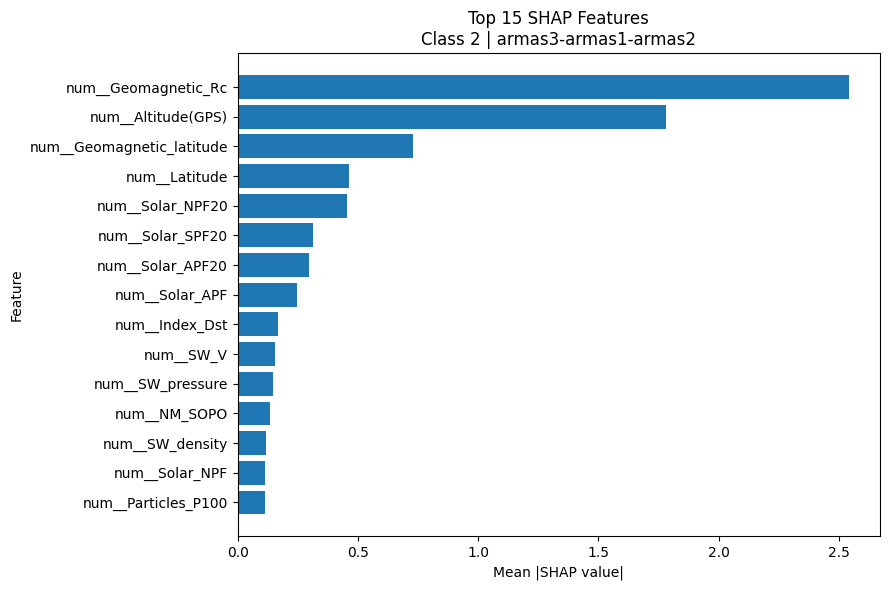


CLASS-SPECIFIC SHAP ROTATION: Train=armas3, Validation=armas2, Test=armas1
Best C selected: 0.385662

Top SHAP features for class 0 in rotation armas3-armas2-armas1:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      0         2.419808    armas3    armas2   
3          num__Altitude(GPS)      0         1.887559    armas3    armas2   
4   num__Geomagnetic_latitude      0         1.313444    armas3    armas2   
0               num__Latitude      0         0.955164    armas3    armas2   
26                 num__SW_Vx      0         0.442195    armas3    armas2   
25                  num__SW_V      0         0.428222    armas3    armas2   
40           num__Solar_NPF20      0         0.236016    armas3    armas2   
11               num__NM_SOPO      0         0.181824    armas3    armas2   
42           num__Solar_APF20      0         0.155369    armas3    armas2   
39             num__Solar_APF      0         0.135124    armas3

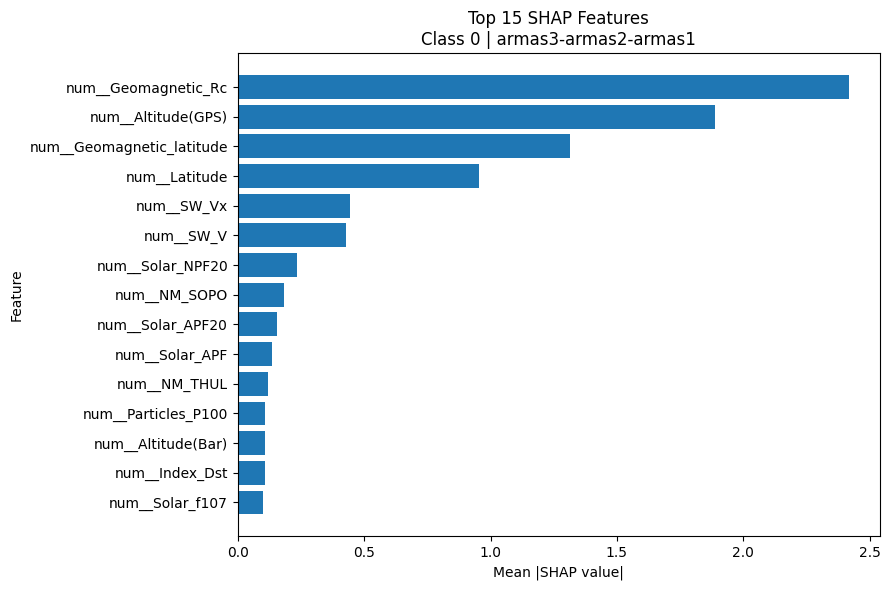


Top SHAP features for class 1 in rotation armas3-armas2-armas1:
                feature  class  shap_importance train_set valid_set test_set  \
40     num__Solar_NPF20      1         0.801586    armas3    armas2   armas1   
42     num__Solar_APF20      1         0.596491    armas3    armas2   armas1   
41     num__Solar_SPF20      1         0.499899    armas3    armas2   armas1   
25            num__SW_V      1         0.380834    armas3    armas2   armas1   
37       num__Solar_NPF      1         0.369045    armas3    armas2   armas1   
26           num__SW_Vx      1         0.339138    armas3    armas2   armas1   
6   num__Geomagnetic_Rc      1         0.308664    armas3    armas2   armas1   
38       num__Solar_SPF      1         0.262127    armas3    armas2   armas1   
39       num__Solar_APF      1         0.140379    armas3    armas2   armas1   
15    num__Particles_P5      1         0.100015    armas3    armas2   armas1   
36      num__Solar_f107      1         0.089002    arma

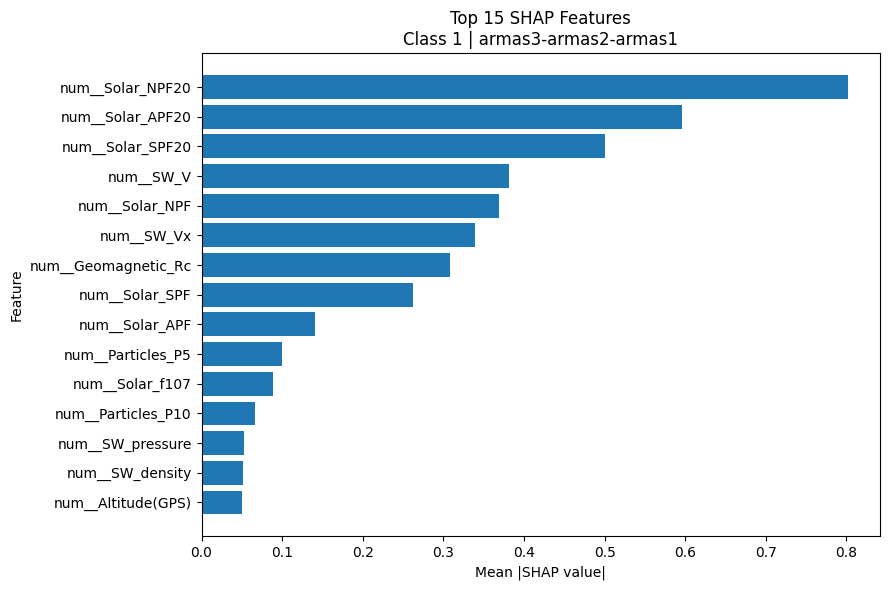


Top SHAP features for class 2 in rotation armas3-armas2-armas1:
                      feature  class  shap_importance train_set valid_set  \
6         num__Geomagnetic_Rc      2         2.728472    armas3    armas2   
3          num__Altitude(GPS)      2         1.937746    armas3    armas2   
4   num__Geomagnetic_latitude      2         1.352862    armas3    armas2   
0               num__Latitude      2         1.001770    armas3    armas2   
40           num__Solar_NPF20      2         0.565569    armas3    armas2   
41           num__Solar_SPF20      2         0.538315    armas3    armas2   
42           num__Solar_APF20      2         0.441122    armas3    armas2   
37             num__Solar_NPF      2         0.424748    armas3    armas2   
38             num__Solar_SPF      2         0.307830    armas3    armas2   
36            num__Solar_f107      2         0.190664    armas3    armas2   
11               num__NM_SOPO      2         0.153957    armas3    armas2   
15         

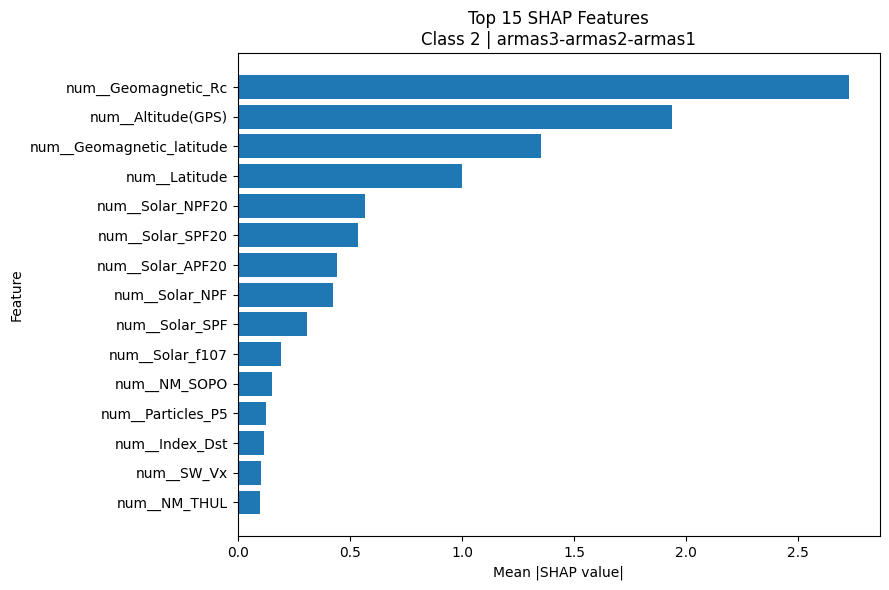


ALL CLASS-SPECIFIC SHAP RESULTS
                     feature  class  shap_importance train_set valid_set  \
0        num__Geomagnetic_Rc      0         1.965652    armas1    armas2   
1         num__Altitude(GPS)      0         1.704947    armas1    armas2   
2  num__Geomagnetic_latitude      0         1.421731    armas1    armas2   
3           num__Solar_NPF20      0         1.212615    armas1    armas2   
4              num__Latitude      0         1.093382    armas1    armas2   

  test_set              rotation  
0   armas3  armas1-armas2-armas3  
1   armas3  armas1-armas2-armas3  
2   armas3  armas1-armas2-armas3  
3   armas3  armas1-armas2-armas3  
4   armas3  armas1-armas2-armas3  

AVERAGE CLASS-SPECIFIC SHAP IMPORTANCE ACROSS ALL ROTATIONS
    class                     feature  avg_shap_importance  \
3       0         num__Geomagnetic_Rc             2.149891   
1       0          num__Altitude(GPS)             1.696714   
4       0   num__Geomagnetic_latitude             0.9

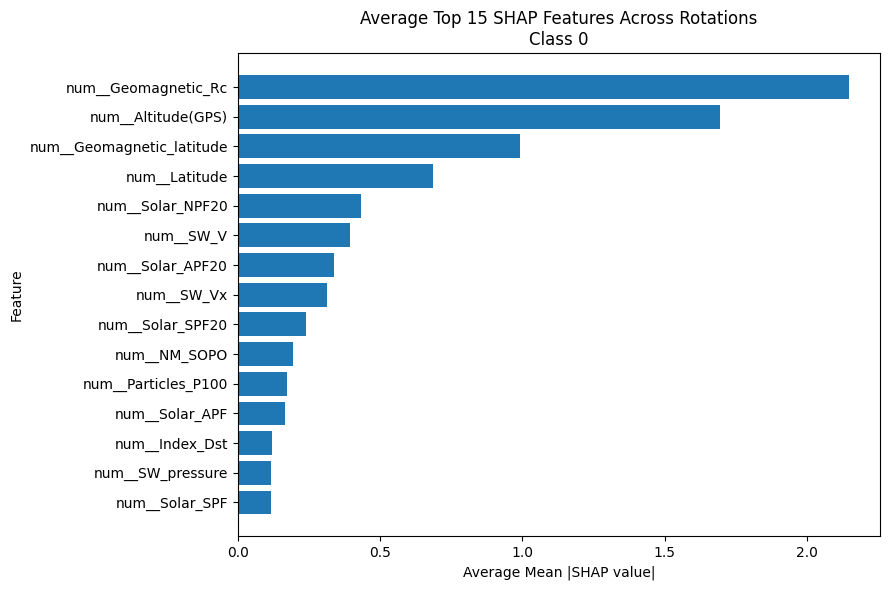

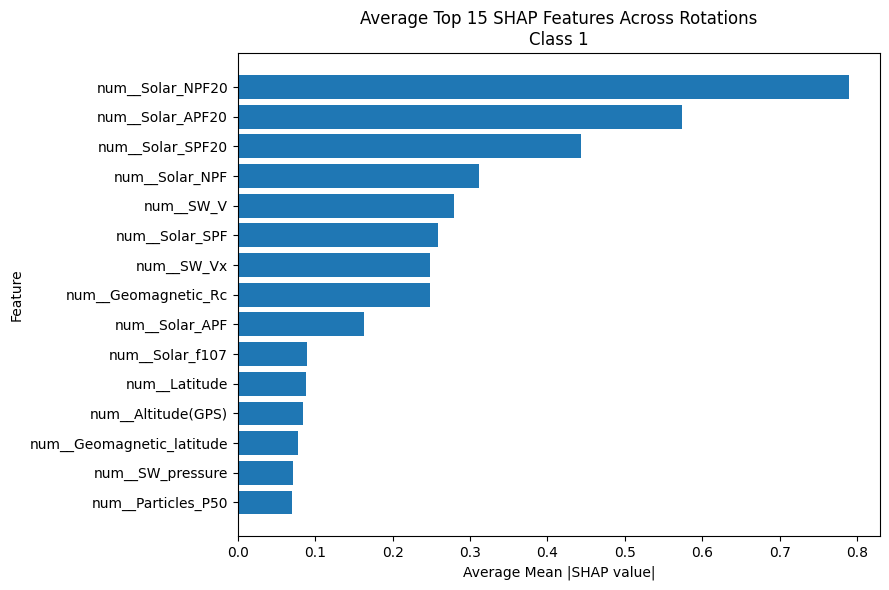

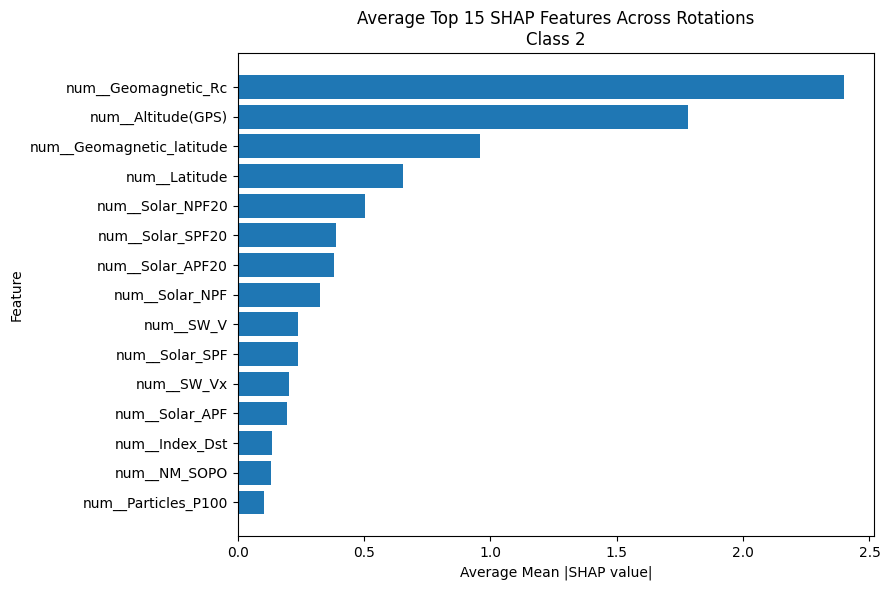


TOP 15 FEATURES PER CLASS (AVERAGED ACROSS ROTATIONS)
     class                    feature  avg_shap_importance  \
3        0        num__Geomagnetic_Rc             2.149891   
1        0         num__Altitude(GPS)             1.696714   
4        0  num__Geomagnetic_latitude             0.992221   
9        0              num__Latitude             0.685967   
38       0           num__Solar_NPF20             0.431886   
26       0                  num__SW_V             0.394643   
36       0           num__Solar_APF20             0.338383   
27       0                 num__SW_Vx             0.314307   
40       0           num__Solar_SPF20             0.238993   
13       0               num__NM_SOPO             0.193192   
18       0        num__Particles_P100             0.172348   
35       0             num__Solar_APF             0.167301   
7        0             num__Index_Dst             0.121078   
31       0           num__SW_pressure             0.118375   
39       0     

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# =========================================================
# CLASS-SPECIFIC SHAP IMPORTANCE ACROSS ALL ROTATIONS
# =========================================================

top_n = 15
all_class_shap_dfs = []

for train_name, valid_name, test_name in rotations:

    print("\n" + "=" * 80)
    print(f"CLASS-SPECIFIC SHAP ROTATION: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print("=" * 80)

    train_df = datasets[train_name].copy()
    valid_df = datasets[valid_name].copy()
    test_df = datasets[test_name].copy()

    X_train, y_train = split_xy(train_df)
    X_valid, y_valid = split_xy(valid_df)
    X_test, y_test = split_xy(test_df)

    # -----------------------------------------------------
    # 1. Tune C on validation set
    # -----------------------------------------------------
    rotation_results = []

    for c in C_values:
        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                C=c,
                max_iter=2000,
                class_weight='balanced',
                solver='lbfgs'
            ))
        ])

        model.fit(X_train, y_train)
        y_valid_pred = model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred, average='macro')

        rotation_results.append({
            'C': c,
            'valid_f1_macro': valid_f1
        })

    rotation_df = pd.DataFrame(rotation_results).sort_values('valid_f1_macro', ascending=False)
    best_c = rotation_df.iloc[0]['C']

    print(f"Best C selected: {best_c:.6f}")

    # -----------------------------------------------------
    # 2. Retrain final model on train + validation
    # -----------------------------------------------------
    X_train_final = pd.concat([X_train, X_valid], axis=0)
    y_train_final = pd.concat([y_train, y_valid], axis=0)

    final_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            C=best_c,
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs'
        ))
    ])

    final_model.fit(X_train_final, y_train_final)

    # -----------------------------------------------------
    # 3. Transform features
    # -----------------------------------------------------
    X_train_final_trans = final_model.named_steps['prep'].transform(X_train_final)
    X_test_trans = final_model.named_steps['prep'].transform(X_test)
    feature_names = final_model.named_steps['prep'].get_feature_names_out()
    clf = final_model.named_steps['clf']
    class_labels = clf.classes_

    # Convert sparse to dense if needed
    if hasattr(X_train_final_trans, "toarray"):
        X_train_final_trans = X_train_final_trans.toarray()
    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    # -----------------------------------------------------
    # 4. Sample background and test subset for SHAP speed
    # -----------------------------------------------------
    background_size = min(200, X_train_final_trans.shape[0])
    test_sample_size = min(300, X_test_trans.shape[0])

    rng = np.random.default_rng(42)

    bg_idx = rng.choice(X_train_final_trans.shape[0], size=background_size, replace=False)
    test_idx = rng.choice(X_test_trans.shape[0], size=test_sample_size, replace=False)

    X_background = X_train_final_trans[bg_idx]
    X_test_sample = X_test_trans[test_idx]

    # -----------------------------------------------------
    # 5. Compute SHAP values
    # -----------------------------------------------------
    explainer = shap.LinearExplainer(clf, X_background)
    shap_values = explainer.shap_values(X_test_sample)

    # -----------------------------------------------------
    # 6. Standardize SHAP output shape to:
    #    (n_samples, n_features, n_classes)
    # -----------------------------------------------------
    if isinstance(shap_values, list):
        shap_array = np.stack(shap_values, axis=-1)
    else:
        shap_array = np.array(shap_values)

        if shap_array.ndim == 3 and shap_array.shape[0] == len(class_labels):
            shap_array = np.moveaxis(shap_array, 0, -1)

    if shap_array.ndim != 3:
        raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

    # -----------------------------------------------------
    # 7. Compute class-specific SHAP importance
    # -----------------------------------------------------
    for class_idx, class_value in enumerate(class_labels):
        class_importance = np.mean(np.abs(shap_array[:, :, class_idx]), axis=0)

        class_shap_df = pd.DataFrame({
            'feature': feature_names,
            'class': class_value,
            'shap_importance': class_importance,
            'train_set': train_name,
            'valid_set': valid_name,
            'test_set': test_name,
            'rotation': f"{train_name}-{valid_name}-{test_name}"
        }).sort_values('shap_importance', ascending=False)

        all_class_shap_dfs.append(class_shap_df)

        print(f"\nTop SHAP features for class {class_value} in rotation {train_name}-{valid_name}-{test_name}:")
        print(class_shap_df.head(top_n))

        # -------------------------------------------------
        # 8. Plot top features for this class in this rotation
        # -------------------------------------------------
        top_class_df = class_shap_df.head(top_n).sort_values('shap_importance')

        plt.figure(figsize=(9, 6))
        plt.barh(top_class_df['feature'], top_class_df['shap_importance'])
        plt.xlabel('Mean |SHAP value|')
        plt.ylabel('Feature')
        plt.title(f'Top {top_n} SHAP Features\nClass {class_value} | {train_name}-{valid_name}-{test_name}')
        plt.tight_layout()
        plt.show()

# =========================================================
# 9. Combine all class-specific SHAP results
# =========================================================
all_class_shap_combined = pd.concat(all_class_shap_dfs, axis=0, ignore_index=True)

print("\n" + "=" * 80)
print("ALL CLASS-SPECIFIC SHAP RESULTS")
print("=" * 80)
print(all_class_shap_combined.head())

# =========================================================
# 10. Average SHAP importance across rotations for each class
# =========================================================
avg_class_shap_df = (
    all_class_shap_combined
    .groupby(['class', 'feature'], as_index=False)
    .agg(
        avg_shap_importance=('shap_importance', 'mean'),
        std_shap_importance=('shap_importance', 'std')
    )
    .sort_values(['class', 'avg_shap_importance'], ascending=[True, False])
)

print("\n" + "=" * 80)
print("AVERAGE CLASS-SPECIFIC SHAP IMPORTANCE ACROSS ALL ROTATIONS")
print("=" * 80)
print(avg_class_shap_df.head(30))

# =========================================================
# 11. Plot average SHAP importance for each class
# =========================================================
for class_value in sorted(avg_class_shap_df['class'].unique()):
    class_avg_df = (
        avg_class_shap_df[avg_class_shap_df['class'] == class_value]
        .sort_values('avg_shap_importance', ascending=False)
    )

    top_avg_df = class_avg_df.head(top_n).sort_values('avg_shap_importance')

    plt.figure(figsize=(9, 6))
    plt.barh(top_avg_df['feature'], top_avg_df['avg_shap_importance'])
    plt.xlabel('Average Mean |SHAP value|')
    plt.ylabel('Feature')
    plt.title(f'Average Top {top_n} SHAP Features Across Rotations\nClass {class_value}')
    plt.tight_layout()
    plt.show()

# =========================================================
# 12. Optional summary tables: top features per class
# =========================================================
top_features_per_class = (
    avg_class_shap_df
    .sort_values(['class', 'avg_shap_importance'], ascending=[True, False])
    .groupby('class')
    .head(top_n)
)

print("\n" + "=" * 80)
print(f"TOP {top_n} FEATURES PER CLASS (AVERAGED ACROSS ROTATIONS)")
print("=" * 80)
print(top_features_per_class)

# =========================================================
# 13. Save results
# =========================================================
# all_class_shap_combined.to_csv("all_rotation_class_specific_shap.csv", index=False)
# avg_class_shap_df.to_csv("average_class_specific_shap_across_rotations.csv", index=False)
# top_features_per_class.to_csv("top_features_per_class_avg_shap.csv", index=False)

print("\nSaved files:")
print("- all_rotation_class_specific_shap.csv")
print("- average_class_specific_shap_across_rotations.csv")
print("- top_features_per_class_avg_shap.csv")